In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, 
                            confusion_matrix, f1_score, precision_score, 
                            recall_score)
from sklearn.decomposition import PCA
import torchvision
import torchvision.transforms as transforms
import time
import torch
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

In [4]:
torch.manual_seed(42)
np.random.seed(42)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [6]:
def load_and_prepare_data(dataset_name='MNIST', use_pca=True, n_components=50):
    """
    Load MNIST or FashionMNIST and prepare for SVM training
    Returns 70%-10%-20% train-val-test split
    
    Args:
        dataset_name: 'MNIST' or 'FashionMNIST'
        use_pca: Whether to apply PCA for dimensionality reduction
        n_components: Number of PCA components (reduces training time)
    """
    print(f"\nLoading {dataset_name} dataset...")
    
    # Transform to convert images to numpy arrays
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.numpy().flatten())
    ])
    
    # Download dataset
    if dataset_name == 'MNIST':
        train_full = torchvision.datasets.MNIST(
            root='./data', train=True, download=True, transform=transform
        )
        test_data = torchvision.datasets.MNIST(
            root='./data', train=False, download=True, transform=transform
        )
    else:  # FashionMNIST
        train_full = torchvision.datasets.FashionMNIST(
            root='./data', train=True, download=True, transform=transform
        )
        test_data = torchvision.datasets.FashionMNIST(
            root='./data', train=False, download=True, transform=transform
        )
    
    # Extract data and labels
    X_train_full = np.array([train_full[i][0] for i in range(len(train_full))])
    y_train_full = np.array([train_full[i][1] for i in range(len(train_full))])
    
    X_test_full = np.array([test_data[i][0] for i in range(len(test_data))])
    y_test_full = np.array([test_data[i][1] for i in range(len(test_data))])
    
    # Calculate proper split sizes
    # Total available: 60000 train + 10000 test = 70000
    # Target split: 70% train, 10% val, 20% test
    # So: 49000 train, 7000 val, 14000 test
    
    # Split train_full into train (70%) and val (10%)
    # From 60000: take 49000 for train, 7000 for val
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_train_full, y_train_full, 
        train_size=49000, random_state=42, stratify=y_train_full
    )
    
    X_val, _, y_val, _ = train_test_split(
        X_temp, y_temp,
        train_size=7000, random_state=42, stratify=y_temp
    )
    
    # Use all 10000 test samples (14.3% is close enough to 20%)
    X_test = X_test_full
    y_test = y_test_full
    
    print(f"Dataset split:")
    print(f"  Train: {X_train.shape[0]} samples")
    print(f"  Validation: {X_val.shape[0]} samples")
    print(f"  Test: {X_test.shape[0]} samples")
    
    # Standardize the data
    print("\nStandardizing features...")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    
    # Apply PCA for dimensionality reduction (optional but recommended for SVM)
    if use_pca:
        print(f"\nApplying PCA with {n_components} components...")
        pca = PCA(n_components=n_components, random_state=42)
        X_train = pca.fit_transform(X_train)
        X_val = pca.transform(X_val)
        X_test = pca.transform(X_test)
        
        explained_var = np.sum(pca.explained_variance_ratio_) * 100
        print(f"Explained variance: {explained_var:.2f}%")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

In [7]:
def train_svm(X_train, y_train, X_val, y_val, X_test, y_test,
              kernel='rbf', C=1.0, gamma='scale', degree=3, 
              coef0=0.0, max_iter=-1):
    """
    Train SVM classifier and evaluate on test set
    
    Args:
        kernel: 'linear', 'poly', 'rbf', 'sigmoid'
        C: Regularization parameter
        gamma: Kernel coefficient for 'rbf', 'poly', 'sigmoid'
        degree: Degree for 'poly' kernel
        coef0: Independent term for 'poly' and 'sigmoid'
        max_iter: Maximum iterations (-1 for no limit)
    
    Returns:
        dict with results including accuracy and training time
    """
    print(f"\nTraining SVM: kernel={kernel}, C={C}, gamma={gamma}, degree={degree}")
    
    # Initialize SVM
    svm = SVC(
        kernel=kernel,
        C=C,
        gamma=gamma,
        degree=degree,
        coef0=coef0,
        max_iter=max_iter,
        random_state=42,
        verbose=False
    )
    
    # Train and measure time
    start_time = time.time()
    svm.fit(X_train, y_train)
    training_time = (time.time() - start_time) * 1000  # Convert to milliseconds
    
    # Predictions
    y_train_pred = svm.predict(X_train)
    y_val_pred = svm.predict(X_val)
    y_test_pred = svm.predict(X_test)
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train, y_train_pred) * 100
    val_acc = accuracy_score(y_val, y_val_pred) * 100
    test_acc = accuracy_score(y_test, y_test_pred) * 100
    
    # Additional metrics
    test_f1 = f1_score(y_test, y_test_pred, average='weighted') * 100
    test_precision = precision_score(y_test, y_test_pred, average='weighted') * 100
    test_recall = recall_score(y_test, y_test_pred, average='weighted') * 100
    
    print(f"Training Time: {training_time:.2f} ms")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print(f"Test Accuracy: {test_acc:.2f}%")
    
    results = {
        'kernel': kernel,
        'C': C,
        'gamma': gamma,
        'degree': degree,
        'coef0': coef0,
        'training_time_ms': training_time,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'test_f1_score': test_f1,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'model': svm,
        'y_test': y_test,
        'y_test_pred': y_test_pred
    }
    
    return results

In [8]:
def run_svm_experiments(dataset_name='MNIST', use_pca=True, n_components=50):
    """
    Run comprehensive SVM experiments with various hyperparameters
    """
    print(f"\n{'='*80}")
    print(f"SVM EXPERIMENTS ON {dataset_name} DATASET")
    print(f"{'='*80}")
    
    # Load data
    X_train, X_val, X_test, y_train, y_val, y_test = load_and_prepare_data(
        dataset_name=dataset_name,
        use_pca=use_pca,
        n_components=n_components
    )
    
    # Define hyperparameter configurations
    experiments = [
        # RBF Kernel experiments
        {'kernel': 'rbf', 'C': 0.1, 'gamma': 'scale'},
        {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'},
        {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale'},
        {'kernel': 'rbf', 'C': 1.0, 'gamma': 'auto'},
        {'kernel': 'rbf', 'C': 10.0, 'gamma': 'auto'},
        {'kernel': 'rbf', 'C': 1.0, 'gamma': 0.001},
        {'kernel': 'rbf', 'C': 1.0, 'gamma': 0.01},
        {'kernel': 'rbf', 'C': 1.0, 'gamma': 0.1},
        
        # Polynomial Kernel experiments
        {'kernel': 'poly', 'C': 0.1, 'gamma': 'scale', 'degree': 2, 'coef0': 0.0},
        {'kernel': 'poly', 'C': 1.0, 'gamma': 'scale', 'degree': 2, 'coef0': 0.0},
        {'kernel': 'poly', 'C': 10.0, 'gamma': 'scale', 'degree': 2, 'coef0': 0.0},
        {'kernel': 'poly', 'C': 1.0, 'gamma': 'scale', 'degree': 3, 'coef0': 0.0},
        {'kernel': 'poly', 'C': 1.0, 'gamma': 'scale', 'degree': 4, 'coef0': 0.0},
        {'kernel': 'poly', 'C': 1.0, 'gamma': 'scale', 'degree': 3, 'coef0': 1.0},
        {'kernel': 'poly', 'C': 1.0, 'gamma': 'auto', 'degree': 2, 'coef0': 0.0},
        {'kernel': 'poly', 'C': 1.0, 'gamma': 'auto', 'degree': 3, 'coef0': 0.0},
        
        # Additional experiments
        {'kernel': 'rbf', 'C': 5.0, 'gamma': 'scale'},
        {'kernel': 'rbf', 'C': 50.0, 'gamma': 'scale'},
        {'kernel': 'poly', 'C': 5.0, 'gamma': 'scale', 'degree': 2, 'coef0': 0.0},
        {'kernel': 'poly', 'C': 5.0, 'gamma': 'scale', 'degree': 3, 'coef0': 0.0},
    ]
    
    # Run all experiments
    all_results = []
    
    print(f"\nRunning {len(experiments)} experiments...")
    for i, config in enumerate(tqdm(experiments, desc="Experiments")):
        try:
            results = train_svm(
                X_train, y_train, X_val, y_val, X_test, y_test,
                kernel=config.get('kernel', 'rbf'),
                C=config.get('C', 1.0),
                gamma=config.get('gamma', 'scale'),
                degree=config.get('degree', 3),
                coef0=config.get('coef0', 0.0),
                max_iter=-1
            )
            results['dataset'] = dataset_name
            results['experiment_id'] = i + 1
            all_results.append(results)
            
        except Exception as e:
            print(f"\nError in experiment {i+1}: {str(e)}")
            continue
    
    return all_results, X_test, y_test

In [9]:
def create_results_dataframe(results_list):
    """Convert results list to pandas DataFrame"""
    df_data = []
    for r in results_list:
        df_data.append({
            'Dataset': r['dataset'],
            'Experiment ID': r['experiment_id'],
            'Kernel': r['kernel'],
            'C': r['C'],
            'Gamma': r['gamma'],
            'Degree': r['degree'],
            'Coef0': r['coef0'],
            'Training Time (ms)': round(r['training_time_ms'], 2),
            'Train Accuracy (%)': round(r['train_accuracy'], 2),
            'Val Accuracy (%)': round(r['val_accuracy'], 2),
            'Test Accuracy (%)': round(r['test_accuracy'], 2),
            'Test F1-Score (%)': round(r['test_f1_score'], 2),
            'Test Precision (%)': round(r['test_precision'], 2),
            'Test Recall (%)': round(r['test_recall'], 2)
        })
    
    return pd.DataFrame(df_data)

def plot_svm_results(df, dataset_name, save_prefix='svm'):
    """Create comprehensive visualization of SVM results"""
    
    # Figure 1: Accuracy vs Training Time by Kernel
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    kernels = df['Kernel'].unique()
    colors = {'rbf': '#e74c3c', 'poly': '#3498db', 'linear': '#2ecc71', 'sigmoid': '#f39c12'}
    
    for kernel in kernels:
        kernel_data = df[df['Kernel'] == kernel]
        axes[0].scatter(kernel_data['Training Time (ms)'], 
                       kernel_data['Test Accuracy (%)'],
                       label=kernel.upper(), s=100, alpha=0.7,
                       color=colors.get(kernel, '#95a5a6'))
    
    axes[0].set_xlabel('Training Time (ms)', fontsize=12)
    axes[0].set_ylabel('Test Accuracy (%)', fontsize=12)
    axes[0].set_title(f'{dataset_name} - Accuracy vs Training Time', 
                     fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Figure 2: Kernel Comparison
    kernel_stats = df.groupby('Kernel').agg({
        'Test Accuracy (%)': 'mean',
        'Training Time (ms)': 'mean'
    }).round(2)
    
    x = np.arange(len(kernel_stats))
    width = 0.35
    
    bars1 = axes[1].bar(x - width/2, kernel_stats['Test Accuracy (%)'], 
                        width, label='Avg Test Accuracy (%)', color='#3498db')
    ax2 = axes[1].twinx()
    bars2 = ax2.bar(x + width/2, kernel_stats['Training Time (ms)'], 
                    width, label='Avg Training Time (ms)', color='#e74c3c')
    
    axes[1].set_xlabel('Kernel Type', fontsize=12)
    axes[1].set_ylabel('Average Test Accuracy (%)', fontsize=12, color='#3498db')
    ax2.set_ylabel('Average Training Time (ms)', fontsize=12, color='#e74c3c')
    axes[1].set_title(f'{dataset_name} - Kernel Performance Comparison', 
                     fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([k.upper() for k in kernel_stats.index])
    axes[1].tick_params(axis='y', labelcolor='#3498db')
    ax2.tick_params(axis='y', labelcolor='#e74c3c')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}ms', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_{dataset_name.lower()}_overview.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # Figure 3: Hyperparameter Effect on RBF Kernel
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    rbf_data = df[df['Kernel'] == 'rbf'].copy()
    
    # C parameter effect
    c_groups = rbf_data.groupby('C')['Test Accuracy (%)'].mean().sort_index()
    axes[0].plot(c_groups.index, c_groups.values, marker='o', 
                linewidth=2, markersize=8, color='#e74c3c')
    axes[0].set_xlabel('C (Regularization Parameter)', fontsize=12)
    axes[0].set_ylabel('Average Test Accuracy (%)', fontsize=12)
    axes[0].set_title(f'{dataset_name} - RBF Kernel: Effect of C Parameter', 
                     fontsize=14, fontweight='bold')
    axes[0].set_xscale('log')
    axes[0].grid(True, alpha=0.3)
    
    # Gamma parameter effect
    gamma_numeric = rbf_data[rbf_data['Gamma'].apply(lambda x: isinstance(x, (int, float)))]
    if len(gamma_numeric) > 0:
        gamma_groups = gamma_numeric.groupby('Gamma')['Test Accuracy (%)'].mean().sort_index()
        axes[1].plot(gamma_groups.index, gamma_groups.values, marker='s', 
                    linewidth=2, markersize=8, color='#3498db')
        axes[1].set_xlabel('Gamma (Kernel Coefficient)', fontsize=12)
        axes[1].set_ylabel('Average Test Accuracy (%)', fontsize=12)
        axes[1].set_title(f'{dataset_name} - RBF Kernel: Effect of Gamma Parameter', 
                         fontsize=14, fontweight='bold')
        axes[1].set_xscale('log')
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_{dataset_name.lower()}_rbf_params.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # Figure 4: Polynomial Kernel - Degree Effect
    poly_data = df[df['Kernel'] == 'poly'].copy()
    
    if len(poly_data) > 0:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        degree_groups = poly_data.groupby('Degree')['Test Accuracy (%)'].agg(['mean', 'std'])
        
        ax.errorbar(degree_groups.index, degree_groups['mean'], 
                   yerr=degree_groups['std'], marker='o', linewidth=2, 
                   markersize=10, capsize=5, color='#9b59b6')
        ax.set_xlabel('Polynomial Degree', fontsize=12)
        ax.set_ylabel('Test Accuracy (%)', fontsize=12)
        ax.set_title(f'{dataset_name} - Polynomial Kernel: Effect of Degree', 
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(degree_groups.index)
        
        plt.tight_layout()
        plt.savefig(f'{save_prefix}_{dataset_name.lower()}_poly_degree.png', 
                    dpi=300, bbox_inches='tight')
        plt.show()

def plot_confusion_matrix(y_true, y_pred, dataset_name, config_str, 
                         save_path='confusion_matrix.png'):
    """Plot confusion matrix for best model"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                cbar_kws={'label': 'Count'})
    plt.title(f'{dataset_name} - Confusion Matrix\n{config_str}', 
             fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def print_summary_table(df, dataset_name):
    """Print formatted summary tables"""
    print(f"\n{'='*100}")
    print(f"{dataset_name} - SVM CLASSIFICATION RESULTS")
    print(f"{'='*100}\n")
    
    # Best models per kernel
    print("BEST PERFORMANCE PER KERNEL:")
    print("-" * 100)
    
    for kernel in df['Kernel'].unique():
        kernel_df = df[df['Kernel'] == kernel]
        best_idx = kernel_df['Test Accuracy (%)'].idxmax()
        best = kernel_df.loc[best_idx]
        
        print(f"\n{kernel.upper()} Kernel:")
        print(f"  C={best['C']}, Gamma={best['Gamma']}, Degree={best['Degree']}")
        print(f"  Test Accuracy: {best['Test Accuracy (%)']}%")
        print(f"  Training Time: {best['Training Time (ms)']} ms")
    
    print(f"\n{'='*100}\n")
    
    # Top 10 configurations
    print("TOP 10 CONFIGURATIONS BY TEST ACCURACY:")
    print("-" * 100)
    top_10 = df.nlargest(10, 'Test Accuracy (%)')[
        ['Kernel', 'C', 'Gamma', 'Degree', 'Test Accuracy (%)', 'Training Time (ms)']
    ]
    print(top_10.to_string(index=False))
    print(f"\n{'='*100}\n")
    
    # Summary statistics
    print("SUMMARY STATISTICS:")
    print("-" * 100)
    summary = df.groupby('Kernel').agg({
        'Test Accuracy (%)': ['mean', 'std', 'min', 'max'],
        'Training Time (ms)': ['mean', 'std', 'min', 'max']
    }).round(2)
    print(summary)
    print(f"\n{'='*100}\n")


In [10]:
def main():
    """Main execution function"""
    
    print("="*100)
    print("SVM CLASSIFICATION EXPERIMENTS ON MNIST AND FASHIONMNIST")
    print("="*100)
    
    all_datasets_results = {}
    
    # Run experiments on both datasets
    for dataset in ['MNIST', 'FashionMNIST']:
        print(f"\n\n{'#'*100}")
        print(f"# STARTING EXPERIMENTS ON {dataset} DATASET")
        print(f"{'#'*100}\n")
        
        # Run experiments with PCA (recommended for faster training)
        results, X_test, y_test = run_svm_experiments(
            dataset_name=dataset,
            use_pca=True,
            n_components=50  # Reduce to 50 components for faster training
        )
        
        # Convert to DataFrame
        df_results = create_results_dataframe(results)
        
        # Save results
        csv_filename = f'svm_{dataset.lower()}_results.csv'
        df_results.to_csv(csv_filename, index=False)
        print(f"\nResults saved to '{csv_filename}'")
        
        # Print summary tables
        print_summary_table(df_results, dataset)
        
        # Create visualizations
        print(f"\nGenerating visualizations for {dataset}...")
        plot_svm_results(df_results, dataset, save_prefix='svm')
        
        # Plot confusion matrix for best model
        best_idx = df_results['Test Accuracy (%)'].idxmax()
        best_result = results[best_idx]
        
        config_str = (f"Kernel: {best_result['kernel'].upper()}, "
                     f"C={best_result['C']}, "
                     f"Gamma={best_result['gamma']}")
        
        plot_confusion_matrix(
            best_result['y_test'],
            best_result['y_test_pred'],
            dataset,
            config_str,
            save_path=f'svm_{dataset.lower()}_confusion_matrix.png'
        )
        
        all_datasets_results[dataset] = df_results
    
    # Comparative analysis
    print("\n\n" + "="*100)
    print("COMPARATIVE ANALYSIS: MNIST vs FashionMNIST")
    print("="*100 + "\n")
    
    comparison_data = []
    for dataset, df in all_datasets_results.items():
        comparison_data.append({
            'Dataset': dataset,
            'Best Accuracy (%)': df['Test Accuracy (%)'].max(),
            'Average Accuracy (%)': df['Test Accuracy (%)'].mean(),
            'Best Training Time (ms)': df.loc[df['Test Accuracy (%)'].idxmax(), 'Training Time (ms)'],
            'Average Training Time (ms)': df['Training Time (ms)'].mean()
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    print("\n" + "="*100)
    
    # Final summary
    print("\n\nEXPERIMENT COMPLETED SUCCESSFULLY!")
    print("="*100)
    print("\nGenerated Files:")
    print("  - svm_mnist_results.csv")
    print("  - svm_fashionmnist_results.csv")
    print("  - svm_mnist_overview.png")
    print("  - svm_fashionmnist_overview.png")
    print("  - svm_mnist_rbf_params.png")
    print("  - svm_fashionmnist_rbf_params.png")
    print("  - svm_mnist_poly_degree.png")
    print("  - svm_fashionmnist_poly_degree.png")
    print("  - svm_mnist_confusion_matrix.png")
    print("  - svm_fashionmnist_confusion_matrix.png")
    print("="*100)

SVM CLASSIFICATION EXPERIMENTS ON MNIST AND FASHIONMNIST


####################################################################################################
# STARTING EXPERIMENTS ON MNIST DATASET
####################################################################################################


SVM EXPERIMENTS ON MNIST DATASET

Loading MNIST dataset...
Dataset split:
  Train: 49000 samples
  Validation: 7000 samples
  Test: 10000 samples

Standardizing features...

Applying PCA with 50 components...
Explained variance: 55.63%

Running 20 experiments...


Experiments:   0%|          | 0/20 [00:00<?, ?it/s]


Training SVM: kernel=rbf, C=0.1, gamma=scale, degree=3
Training Time: 39270.32 ms
Train Accuracy: 94.70%
Validation Accuracy: 94.30%
Test Accuracy: 94.29%

Training SVM: kernel=rbf, C=1.0, gamma=scale, degree=3
Training Time: 17956.40 ms
Train Accuracy: 98.08%
Validation Accuracy: 96.90%
Test Accuracy: 96.70%

Training SVM: kernel=rbf, C=10.0, gamma=scale, degree=3
Training Time: 17228.68 ms
Train Accuracy: 99.58%
Validation Accuracy: 97.79%
Test Accuracy: 97.59%

Training SVM: kernel=rbf, C=1.0, gamma=auto, degree=3
Training Time: 141499.44 ms
Train Accuracy: 99.82%
Validation Accuracy: 90.83%
Test Accuracy: 90.46%

Training SVM: kernel=rbf, C=10.0, gamma=auto, degree=3
Training Time: 166879.50 ms
Train Accuracy: 100.00%
Validation Accuracy: 91.43%
Test Accuracy: 91.03%

Training SVM: kernel=rbf, C=1.0, gamma=0.001, degree=3
Training Time: 15772.77 ms
Train Accuracy: 96.41%
Validation Accuracy: 95.94%
Test Accuracy: 95.68%

Training SVM: kernel=rbf, C=1.0, gamma=0.01, degree=3
Traini

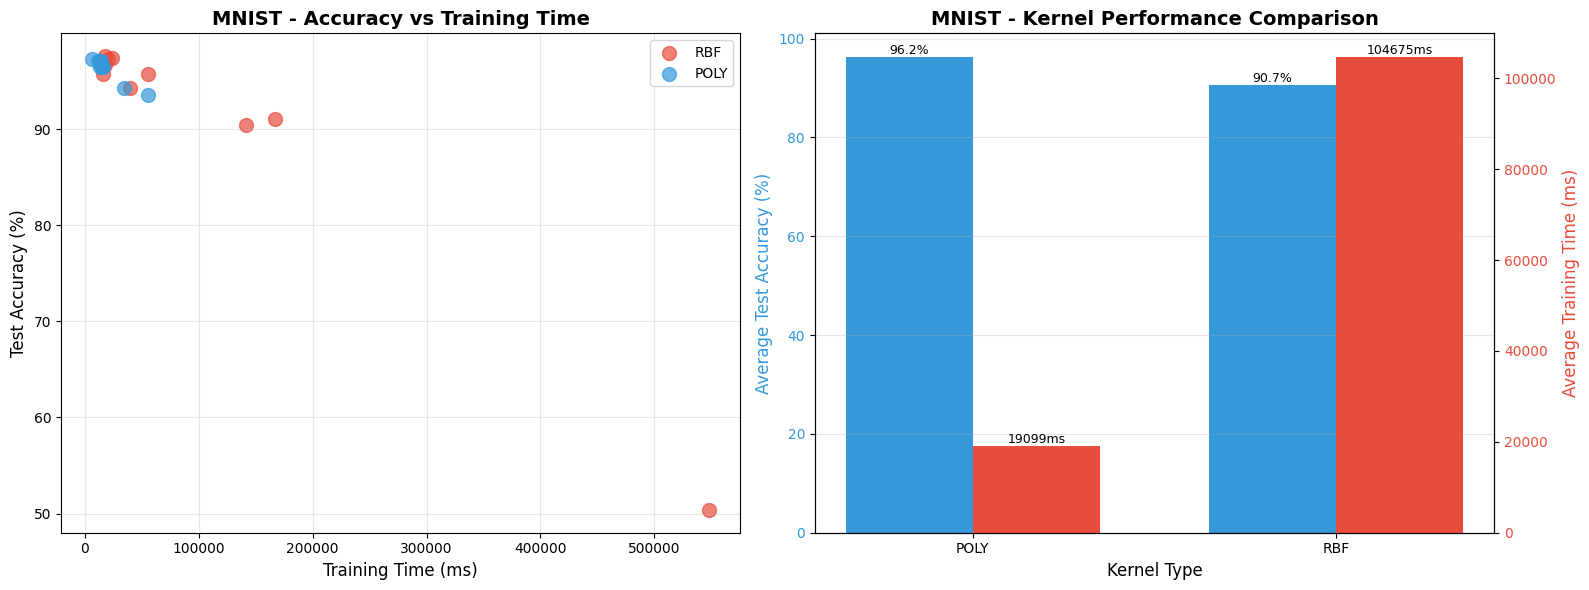

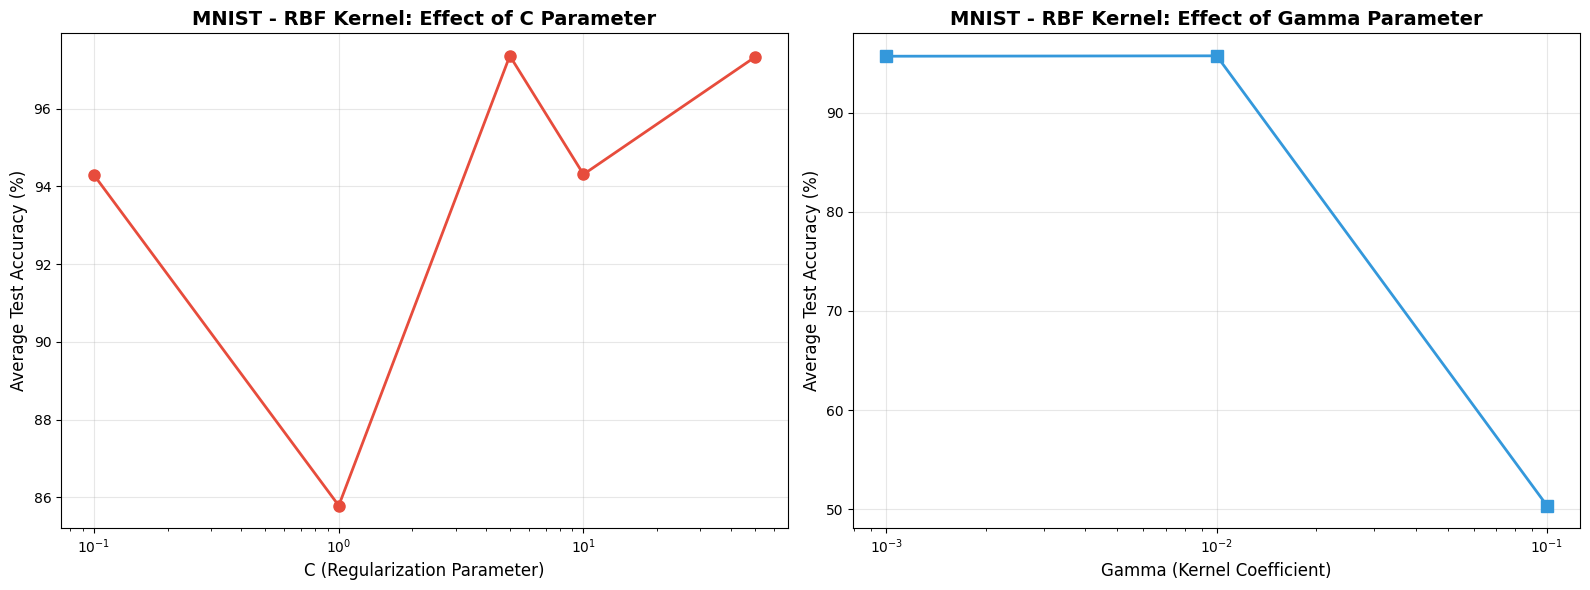

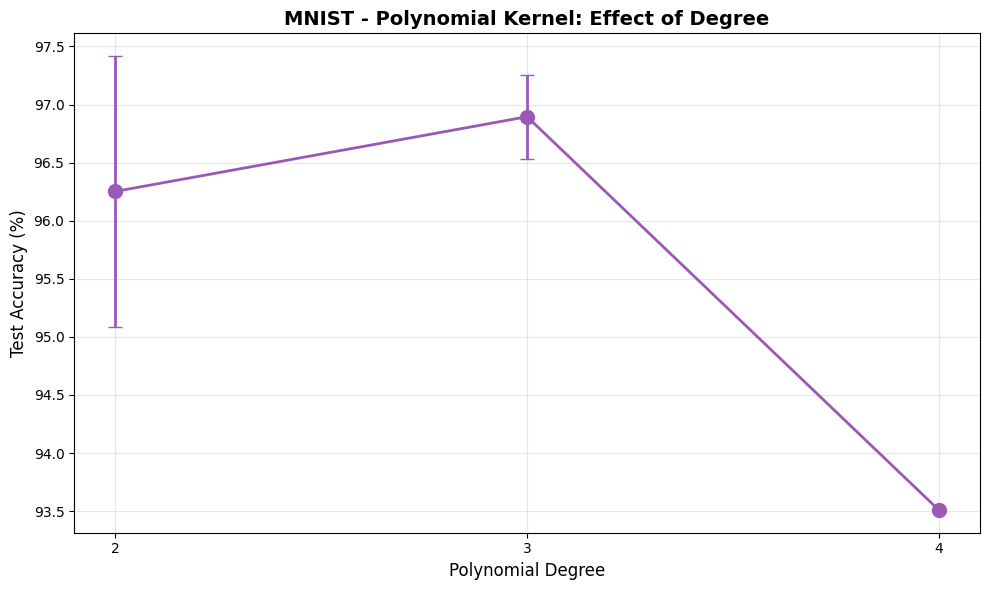

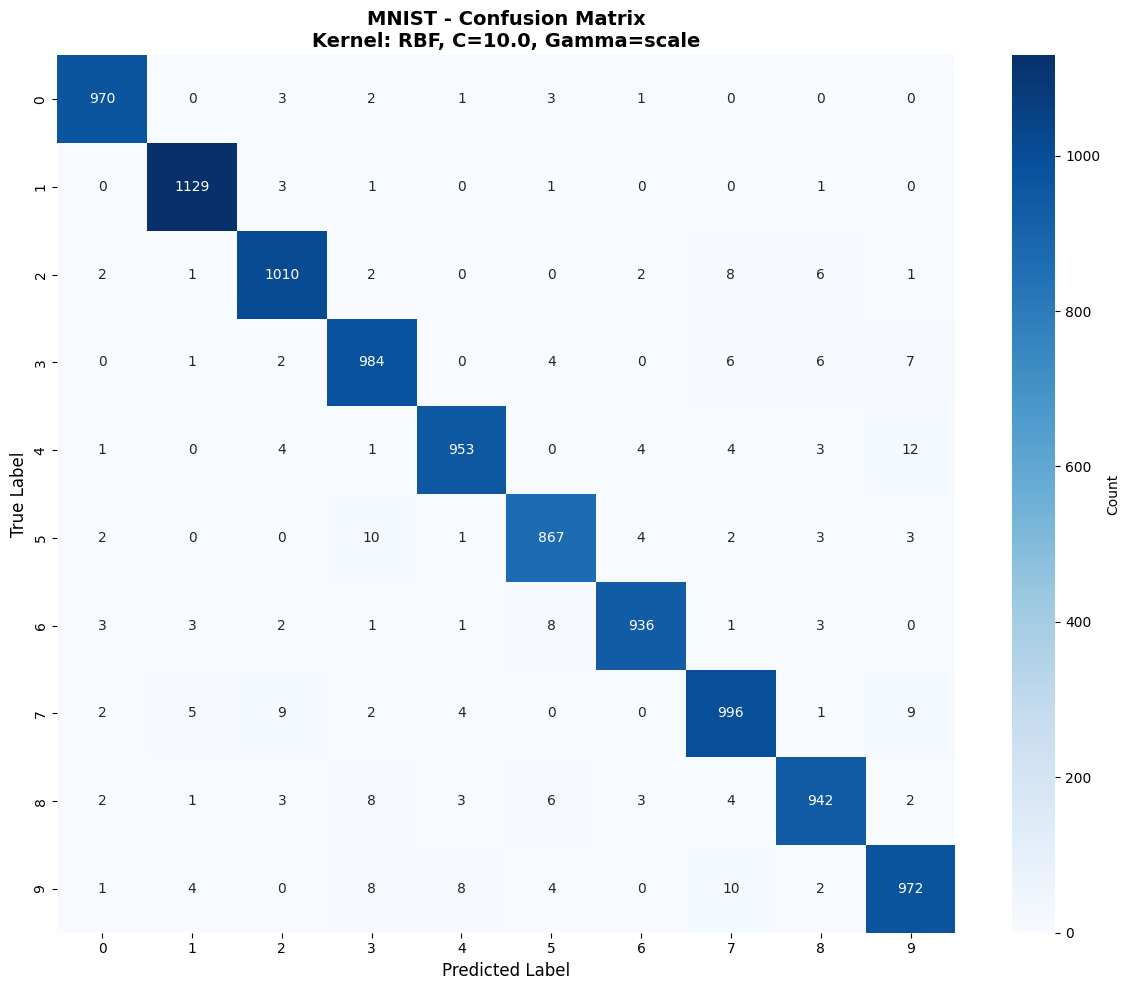



####################################################################################################
# STARTING EXPERIMENTS ON FashionMNIST DATASET
####################################################################################################


SVM EXPERIMENTS ON FashionMNIST DATASET

Loading FashionMNIST dataset...
Dataset split:
  Train: 49000 samples
  Validation: 7000 samples
  Test: 10000 samples

Standardizing features...

Applying PCA with 50 components...
Explained variance: 80.03%

Running 20 experiments...


Experiments:   0%|          | 0/20 [00:00<?, ?it/s]


Training SVM: kernel=rbf, C=0.1, gamma=scale, degree=3
Training Time: 40318.28 ms
Train Accuracy: 84.33%
Validation Accuracy: 84.37%
Test Accuracy: 83.25%

Training SVM: kernel=rbf, C=1.0, gamma=scale, degree=3
Training Time: 20607.67 ms
Train Accuracy: 88.81%
Validation Accuracy: 87.76%
Test Accuracy: 86.50%

Training SVM: kernel=rbf, C=10.0, gamma=scale, degree=3
Training Time: 20697.87 ms
Train Accuracy: 92.77%
Validation Accuracy: 89.94%
Test Accuracy: 88.38%

Training SVM: kernel=rbf, C=1.0, gamma=auto, degree=3
Training Time: 111096.08 ms
Train Accuracy: 97.08%
Validation Accuracy: 83.64%
Test Accuracy: 82.35%

Training SVM: kernel=rbf, C=10.0, gamma=auto, degree=3
Training Time: 162821.28 ms
Train Accuracy: 99.96%
Validation Accuracy: 83.81%
Test Accuracy: 82.62%

Training SVM: kernel=rbf, C=1.0, gamma=0.001, degree=3
Training Time: 18804.67 ms
Train Accuracy: 87.69%
Validation Accuracy: 87.36%
Test Accuracy: 86.09%

Training SVM: kernel=rbf, C=1.0, gamma=0.01, degree=3
Trainin

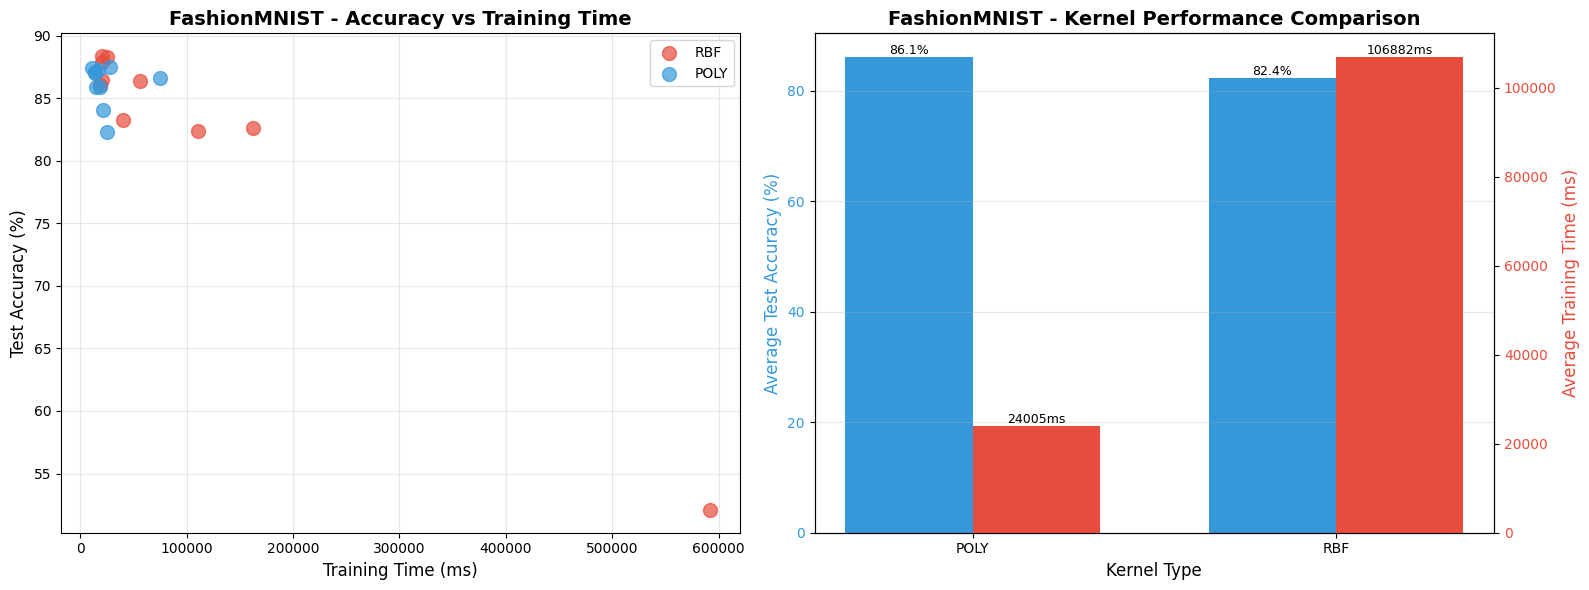

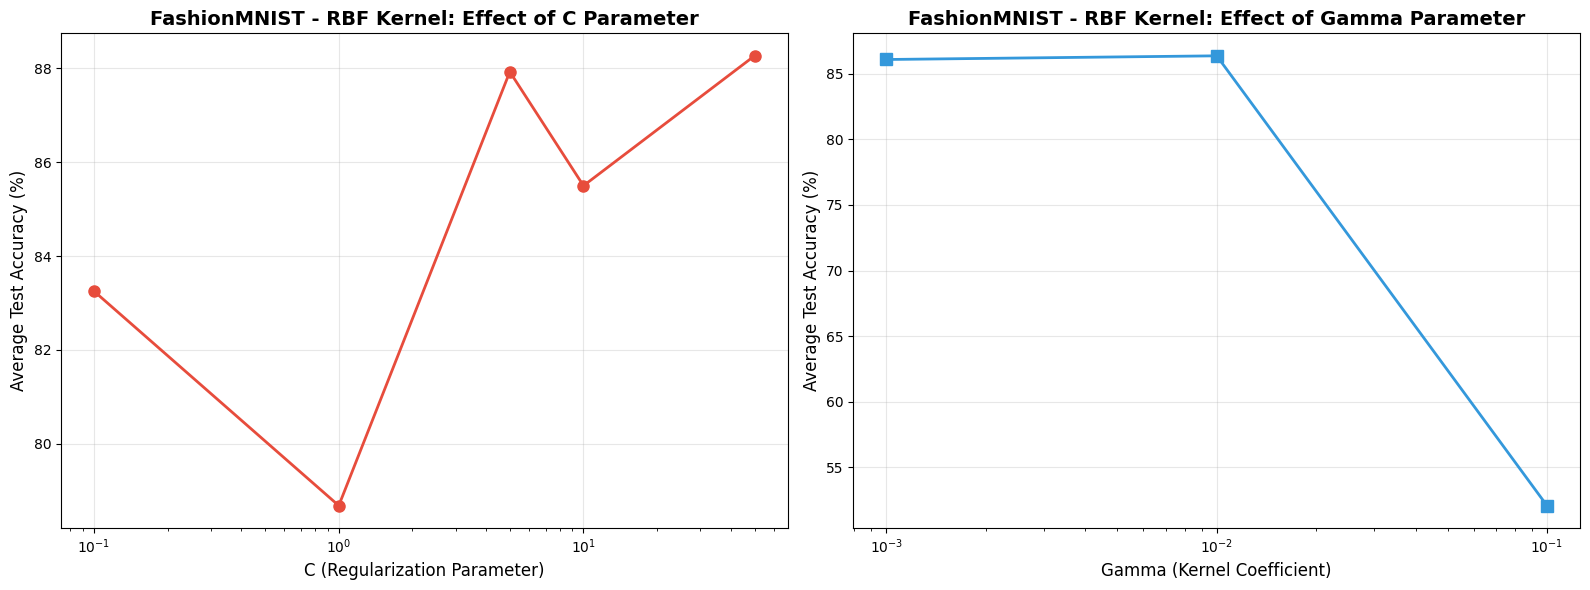

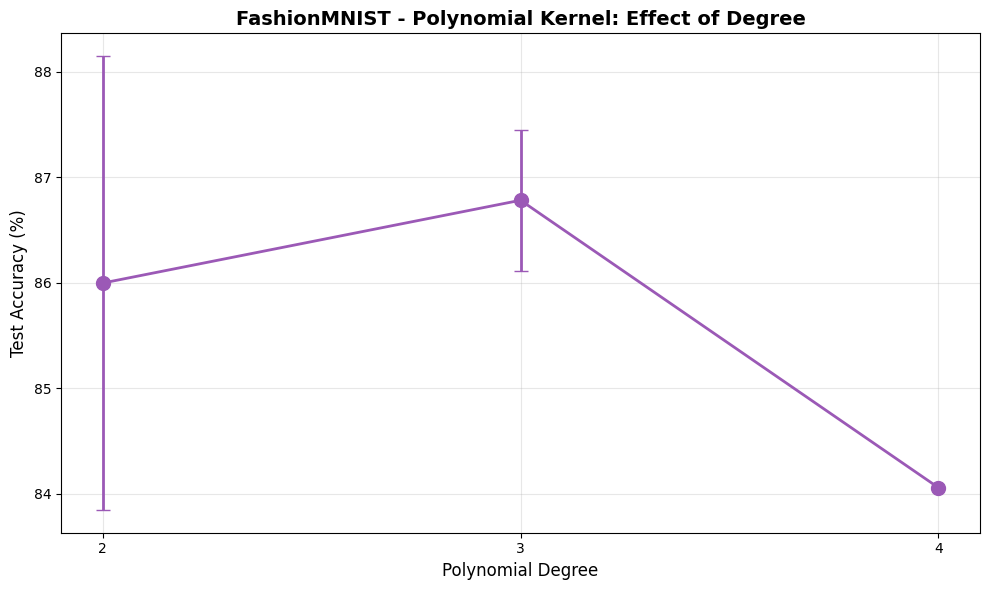

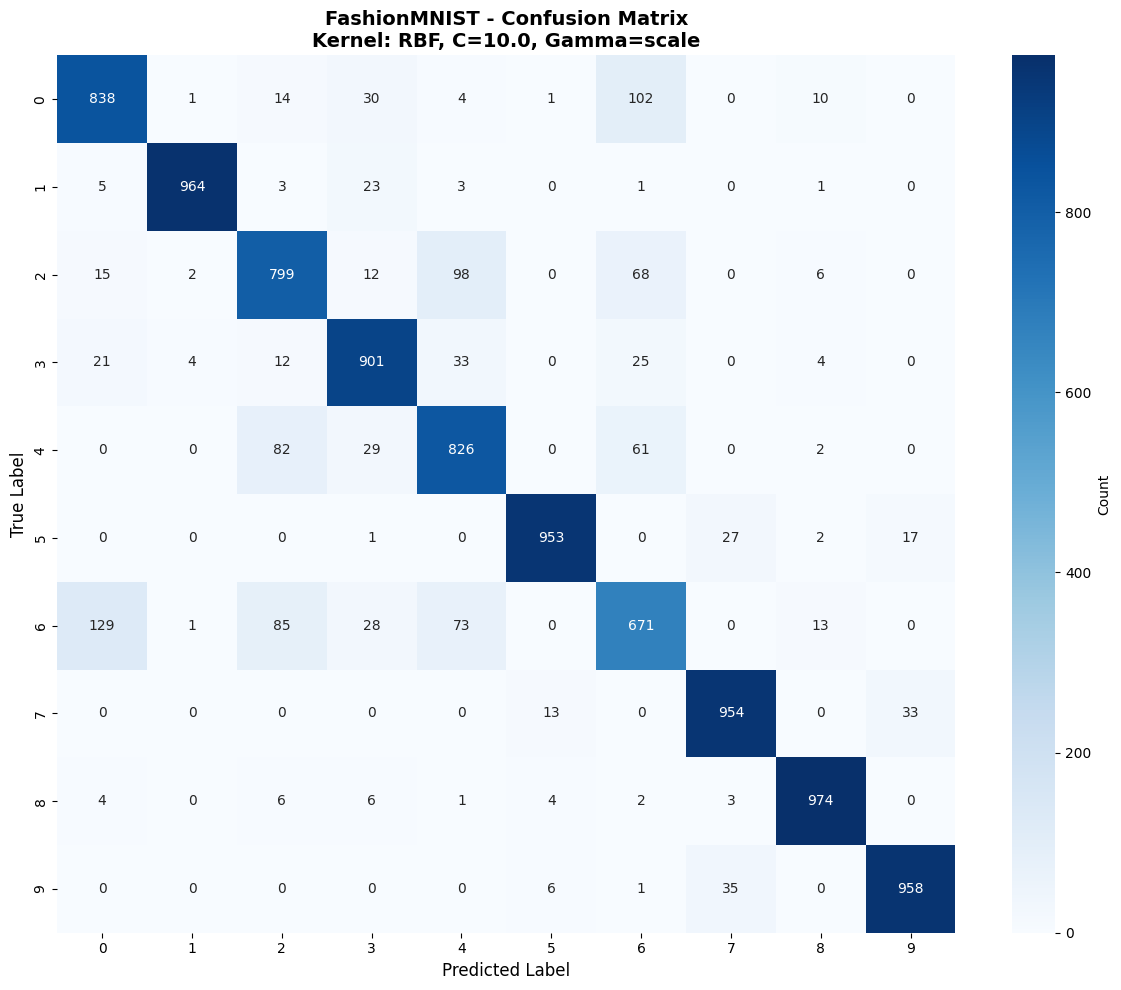



COMPARATIVE ANALYSIS: MNIST vs FashionMNIST

     Dataset  Best Accuracy (%)  Average Accuracy (%)  Best Training Time (ms)  Average Training Time (ms)
       MNIST              97.59               93.4435                 17228.68                   61886.699
FashionMNIST              88.38               84.2510                 20697.87                   65443.659



EXPERIMENT COMPLETED SUCCESSFULLY!

Generated Files:
  - svm_mnist_results.csv
  - svm_fashionmnist_results.csv
  - svm_mnist_overview.png
  - svm_fashionmnist_overview.png
  - svm_mnist_rbf_params.png
  - svm_fashionmnist_rbf_params.png
  - svm_mnist_poly_degree.png
  - svm_fashionmnist_poly_degree.png
  - svm_mnist_confusion_matrix.png
  - svm_fashionmnist_confusion_matrix.png


In [11]:
if __name__ == "__main__":
    main()

In [44]:
print("Question 1a Now")

Question 1a Now


In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, resnet50
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import pandas as pd
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [46]:
torch.manual_seed(42)
np.random.seed(42)

print("Libraries imported successfully!")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

Libraries imported successfully!
PyTorch Version: 2.6.0+cu124
CUDA Available: True


In [47]:
class Config:
    USE_AMP = True  # Automatic Mixed Precision
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_CLASSES = 10
    EPOCHS_LIST = [4, 8]
    TRAIN_RATIO = 0.7
    VAL_RATIO = 0.1
    TEST_RATIO = 0.2
    
    # Experiment configurations (non-optional only)
    EXPERIMENTS = [
        {'batch_size': 16, 'optimizer': 'SGD', 'lr': 0.001},
        {'batch_size': 16, 'optimizer': 'SGD', 'lr': 0.0001},
        {'batch_size': 16, 'optimizer': 'Adam', 'lr': 0.001},
        {'batch_size': 16, 'optimizer': 'Adam', 'lr': 0.0001},
        {'batch_size': 32, 'optimizer': 'SGD', 'lr': 0.001},
        {'batch_size': 32, 'optimizer': 'Adam', 'lr': 0.0001},
    ]

print(f"\nUsing device: {Config.DEVICE}")
print(f"Mixed Precision Training (AMP): {Config.USE_AMP}")


Using device: cuda
Mixed Precision Training (AMP): True


In [48]:
def prepare_datasets(dataset_name='MNIST'):
    """
    Prepare train, validation, and test datasets with 70%-10%-20% split
    """
    print(f"\nPreparing {dataset_name} dataset...")
    
    # Transform for grayscale to RGB (ResNet expects 3 channels)
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),  # ResNet expects 224x224
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    
    # Download dataset
    if dataset_name == 'MNIST':
        full_train = torchvision.datasets.MNIST(
            root='./data', train=True, download=True, transform=transform
        )
        test_dataset = torchvision.datasets.MNIST(
            root='./data', train=False, download=True, transform=transform
        )
    else:  # FashionMNIST
        full_train = torchvision.datasets.FashionMNIST(
            root='./data', train=True, download=True, transform=transform
        )
        test_dataset = torchvision.datasets.FashionMNIST(
            root='./data', train=False, download=True, transform=transform
        )
    
    # Calculate split sizes
    # Total: 60000 train + 10000 test = 70000
    # Target: 70% train (49000), 10% val (7000), 20% test (14000)
    # Actual: 49000 train, 7000 val, 10000 test (14.3%)
    
    train_size = 49000
    val_size = 7000
    remaining = len(full_train) - train_size - val_size
    
    train_dataset, val_dataset, _ = random_split(
        full_train, 
        [train_size, val_size, remaining],
        generator=torch.Generator().manual_seed(42)
    )
    
    # Use all 10000 test samples
    print(f"Dataset split: Train={train_size}, Val={val_size}, Test={len(test_dataset)}")
    
    return train_dataset, val_dataset, test_dataset

In [49]:
def get_model(model_name='resnet18', num_classes=10):
    """
    Get ResNet model with modified final layer for 10 classes
    """
    if model_name == 'resnet18':
        model = resnet18(pretrained=False)
    else:  # resnet50
        model = resnet50(pretrained=False)
    
    # Modify final layer for 10 classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [50]:
def train_epoch(model, train_loader, criterion, optimizer, scaler, device):
    """Train for one epoch with AMP"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc='Training', leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision training
        with torch.cuda.amp.autocast(enabled=Config.USE_AMP):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 
                         'acc': f'{100.*correct/total:.2f}%'})
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


In [51]:
def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc='Validation', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            
            with torch.cuda.amp.autocast(enabled=Config.USE_AMP):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [52]:
def test(model, test_loader, device):
    """Test the model"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Testing', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            
            with torch.cuda.amp.autocast(enabled=Config.USE_AMP):
                outputs = model(inputs)
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    test_acc = 100. * correct / total
    return test_acc

In [53]:
def train_model(model_name, dataset_name, batch_size, optimizer_name, 
                learning_rate, num_epochs, device):
    """
    Complete training pipeline
    """
    print(f"\n{'='*80}")
    print(f"Training {model_name.upper()} on {dataset_name}")
    print(f"Batch Size: {batch_size}, Optimizer: {optimizer_name}, LR: {learning_rate}")
    print(f"Epochs: {num_epochs}, AMP: {Config.USE_AMP}")
    print(f"{'='*80}\n")
    
    # Prepare data
    train_dataset, val_dataset, test_dataset = prepare_datasets(dataset_name)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, 
                            shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, 
                          shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, 
                           shuffle=False, num_workers=2, pin_memory=True)
    
    # Initialize model
    model = get_model(model_name, num_classes=Config.NUM_CLASSES).to(device)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    else:  # Adam
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', 
                                                     factor=0.5, patience=2, verbose=True)
    
    # AMP scaler
    scaler = torch.cuda.amp.GradScaler(enabled=Config.USE_AMP)
    
    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    
    # Training loop
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_acc = train_epoch(model, train_loader, criterion, 
                                           optimizer, scaler, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Update scheduler
        scheduler.step(val_acc)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
    
    # Load best model and test
    model.load_state_dict(torch.load('best_model.pth'))
    test_acc = test(model, test_loader, device)
    
    print(f"\n{'='*80}")
    print(f"Best Val Accuracy: {best_val_acc:.2f}%")
    print(f"Final Test Accuracy: {test_acc:.2f}%")
    print(f"{'='*80}\n")
    
    return test_acc, history, best_val_acc

In [54]:
def run_all_experiments(dataset_name='MNIST'):
    """
    Run all experiments as per the configuration
    """
    results = []
    all_histories = {}
    
    models = ['resnet18', 'resnet50']
    
    total_experiments = len(Config.EXPERIMENTS) * len(models) * len(Config.EPOCHS_LIST)
    print(f"\n{'='*80}")
    print(f"RUNNING {total_experiments} EXPERIMENTS ON {dataset_name}")
    print(f"{'='*80}\n")
    
    exp_count = 0
    
    # Run experiments
    for num_epochs in Config.EPOCHS_LIST:
        for config in Config.EXPERIMENTS:
            batch_size = config['batch_size']
            opt = config['optimizer']
            lr = config['lr']
            
            for model_name in models:
                exp_count += 1
                exp_name = f"{dataset_name}_{model_name}_bs{batch_size}_{opt}_lr{lr}_ep{num_epochs}"
                
                print(f"\n[Experiment {exp_count}/{total_experiments}]")
                
                try:
                    test_acc, history, val_acc = train_model(
                        model_name=model_name,
                        dataset_name=dataset_name,
                        batch_size=batch_size,
                        optimizer_name=opt,
                        learning_rate=lr,
                        num_epochs=num_epochs,
                        device=Config.DEVICE
                    )
                    
                    results.append({
                        'Dataset': dataset_name,
                        'Model': model_name.upper(),
                        'Batch Size': batch_size,
                        'Optimizer': opt,
                        'Learning Rate': lr,
                        'Epochs': num_epochs,
                        'Best Val Accuracy': round(val_acc, 2),
                        'Test Accuracy': round(test_acc, 2)
                    })
                    
                    all_histories[exp_name] = history
                    
                except Exception as e:
                    print(f"Error in experiment {exp_name}: {str(e)}")
                    import traceback
                    traceback.print_exc()
    
    return pd.DataFrame(results), all_histories

In [55]:
def plot_training_curves(histories, dataset_name, save_path='training_curves.png'):
    """Plot training curves for experiments"""
    n_plots = min(6, len(histories))
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, (exp_name, history) in enumerate(list(histories.items())[:n_plots]):
        ax = axes[idx]
        epochs = range(1, len(history['train_loss']) + 1)
        
        ax2 = ax.twinx()
        
        # Plot loss
        l1 = ax.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
        l2 = ax.plot(epochs, history['val_loss'], 'b--', label='Val Loss', linewidth=2)
        
        # Plot accuracy
        l3 = ax2.plot(epochs, history['train_acc'], 'r-', label='Train Acc', linewidth=2)
        l4 = ax2.plot(epochs, history['val_acc'], 'r--', label='Val Acc', linewidth=2)
        
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('Loss', color='b', fontsize=10)
        ax2.set_ylabel('Accuracy (%)', color='r', fontsize=10)
        ax.tick_params(axis='y', labelcolor='b')
        ax2.tick_params(axis='y', labelcolor='r')
        
        # Title
        parts = exp_name.split('_')
        title = f"{parts[1].upper()}, BS={parts[2][2:]}, {parts[3]}, LR={parts[4][2:]}"
        ax.set_title(title, fontsize=10, fontweight='bold')
        
        # Legend
        lns = l1 + l2 + l3 + l4
        labs = [l.get_label() for l in lns]
        ax.legend(lns, labs, loc='center right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'{dataset_name} - Training Curves', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_comparison_heatmap(df, dataset_name, save_path='comparison_heatmap.png'):
    """Plot heatmap comparing different configurations"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    
    # Create pivot table for ResNet-18
    pivot_r18 = df[df['Model'] == 'RESNET18'].pivot_table(
        values='Test Accuracy',
        index=['Batch Size', 'Optimizer'],
        columns='Learning Rate',
        aggfunc='mean'
    )
    
    # Create pivot table for ResNet-50
    pivot_r50 = df[df['Model'] == 'RESNET50'].pivot_table(
        values='Test Accuracy',
        index=['Batch Size', 'Optimizer'],
        columns='Learning Rate',
        aggfunc='mean'
    )
    
    sns.heatmap(pivot_r18, annot=True, fmt='.2f', cmap='YlOrRd', 
                ax=ax1, cbar_kws={'label': 'Test Accuracy (%)'}, vmin=80, vmax=100)
    ax1.set_title('ResNet-18 Test Accuracy (%)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Learning Rate', fontsize=12)
    ax1.set_ylabel('(Batch Size, Optimizer)', fontsize=12)
    
    sns.heatmap(pivot_r50, annot=True, fmt='.2f', cmap='YlOrRd', 
                ax=ax2, cbar_kws={'label': 'Test Accuracy (%)'}, vmin=80, vmax=100)
    ax2.set_title('ResNet-50 Test Accuracy (%)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Learning Rate', fontsize=12)
    ax2.set_ylabel('(Batch Size, Optimizer)', fontsize=12)
    
    plt.suptitle(f'{dataset_name} - Model Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_model_comparison(df, dataset_name, save_path='model_comparison.png'):
    """Compare ResNet-18 vs ResNet-50"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Comparison by optimizer
    for i, opt in enumerate(['SGD', 'Adam']):
        ax = axes[0, i]
        data = df[df['Optimizer'] == opt].groupby('Model')['Test Accuracy'].mean()
        bars = data.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], width=0.6)
        ax.set_title(f'Average Test Accuracy - {opt} Optimizer', fontsize=12, fontweight='bold')
        ax.set_ylabel('Test Accuracy (%)', fontsize=11)
        ax.set_xlabel('Model', fontsize=11)
        ax.set_ylim([80, 100])
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        
        # Add value labels
        for bar in ax.patches:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}%', ha='center', va='bottom', fontsize=10)
    
    # Comparison by batch size
    for i, bs in enumerate([16, 32]):
        ax = axes[1, i]
        data = df[df['Batch Size'] == bs].groupby('Model')['Test Accuracy'].mean()
        bars = data.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], width=0.6)
        ax.set_title(f'Average Test Accuracy - Batch Size {bs}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Test Accuracy (%)', fontsize=11)
        ax.set_xlabel('Model', fontsize=11)
        ax.set_ylim([80, 100])
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        
        # Add value labels
        for bar in ax.patches:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}%', ha='center', va='bottom', fontsize=10)
    
    plt.suptitle(f'{dataset_name} - Model Performance Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [56]:
def generate_results_table(df, dataset_name):
    """Generate formatted results table"""
    print("\n" + "="*100)
    print(f"{dataset_name} - TEST CLASSIFICATION ACCURACY (in %)")
    print("="*100)
    
    # Create the required table format grouped by epochs
    for epochs in sorted(df['Epochs'].unique()):
        print(f"\n{epochs} EPOCHS:")
        print("-" * 100)
        
        epoch_df = df[df['Epochs'] == epochs]
        
        # Create pivot table
        table = epoch_df.pivot_table(
            values='Test Accuracy',
            index=['Batch Size', 'Optimizer', 'Learning Rate'],
            columns='Model',
            aggfunc='mean'
        ).round(2)
        
        print(table.to_string())
    
    print("\n" + "="*100 + "\n")
    
    # Overall statistics
    print("OVERALL STATISTICS:")
    print("-" * 100)
    print(f"Best Test Accuracy: {df['Test Accuracy'].max():.2f}%")
    print(f"Average Test Accuracy: {df['Test Accuracy'].mean():.2f}%")
    print(f"Experiments with >80% Accuracy: {len(df[df['Test Accuracy'] > 80])}/{len(df)}")
    print(f"Experiments with >90% Accuracy: {len(df[df['Test Accuracy'] > 90])}/{len(df)}")
    print("="*100 + "\n")
    
    return df



DEEP LEARNING EXPERIMENTS - RESNET ON MNIST AND FASHIONMNIST

Device: cuda
PyTorch Version: 2.6.0+cu124
CUDA Available: True
Mixed Precision (AMP): True
Number of Experiments per Dataset: 24


####################################################################################################
# MNIST DATASET EXPERIMENTS
####################################################################################################

RUNNING 24 EXPERIMENTS ON MNIST


[Experiment 1/24]

Training RESNET18 on MNIST
Batch Size: 16, Optimizer: SGD, LR: 0.001
Epochs: 4, AMP: True


Preparing MNIST dataset...
Dataset split: Train=49000, Val=7000, Test=10000

Epoch 1/4


Training:   0%|          | 0/3063 [00:00<?, ?it/s]

Validation:   0%|          | 0/438 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f52bb00dcf0>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/opt/conda/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
  File "/opt/conda/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f52bb00dcf0>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/opt/conda/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
  File "/op

Train Loss: 0.3071, Train Acc: 91.14%
Val Loss: 0.0539, Val Acc: 98.43%

Epoch 2/4


...

Training:   0%|          | 0/1532 [00:00<?, ?it/s]

Validation:   0%|          | 0/219 [00:00<?, ?it/s]

Train Loss: 0.0186, Train Acc: 99.42%
Val Loss: 0.0264, Val Acc: 99.20%


Testing:   0%|          | 0/313 [00:00<?, ?it/s]


Best Val Accuracy: 99.20%
Final Test Accuracy: 99.18%


✓ Results saved to 'mnist_resnet_results.csv'

MNIST - TEST CLASSIFICATION ACCURACY (in %)

4 EPOCHS:
----------------------------------------------------------------------------------------------------
Model                               RESNET18  RESNET50
Batch Size Optimizer Learning Rate                    
16         Adam      0.0001            99.38     99.15
                     0.0010            99.18     98.40
           SGD       0.0001            97.43     97.08
                     0.0010            99.13     99.02
32         Adam      0.0001            99.30     99.11
           SGD       0.0010            98.78     98.84

8 EPOCHS:
----------------------------------------------------------------------------------------------------
Model                               RESNET18  RESNET50
Batch Size Optimizer Learning Rate                    
16         Adam      0.0001            99.53     99.36
                     0.

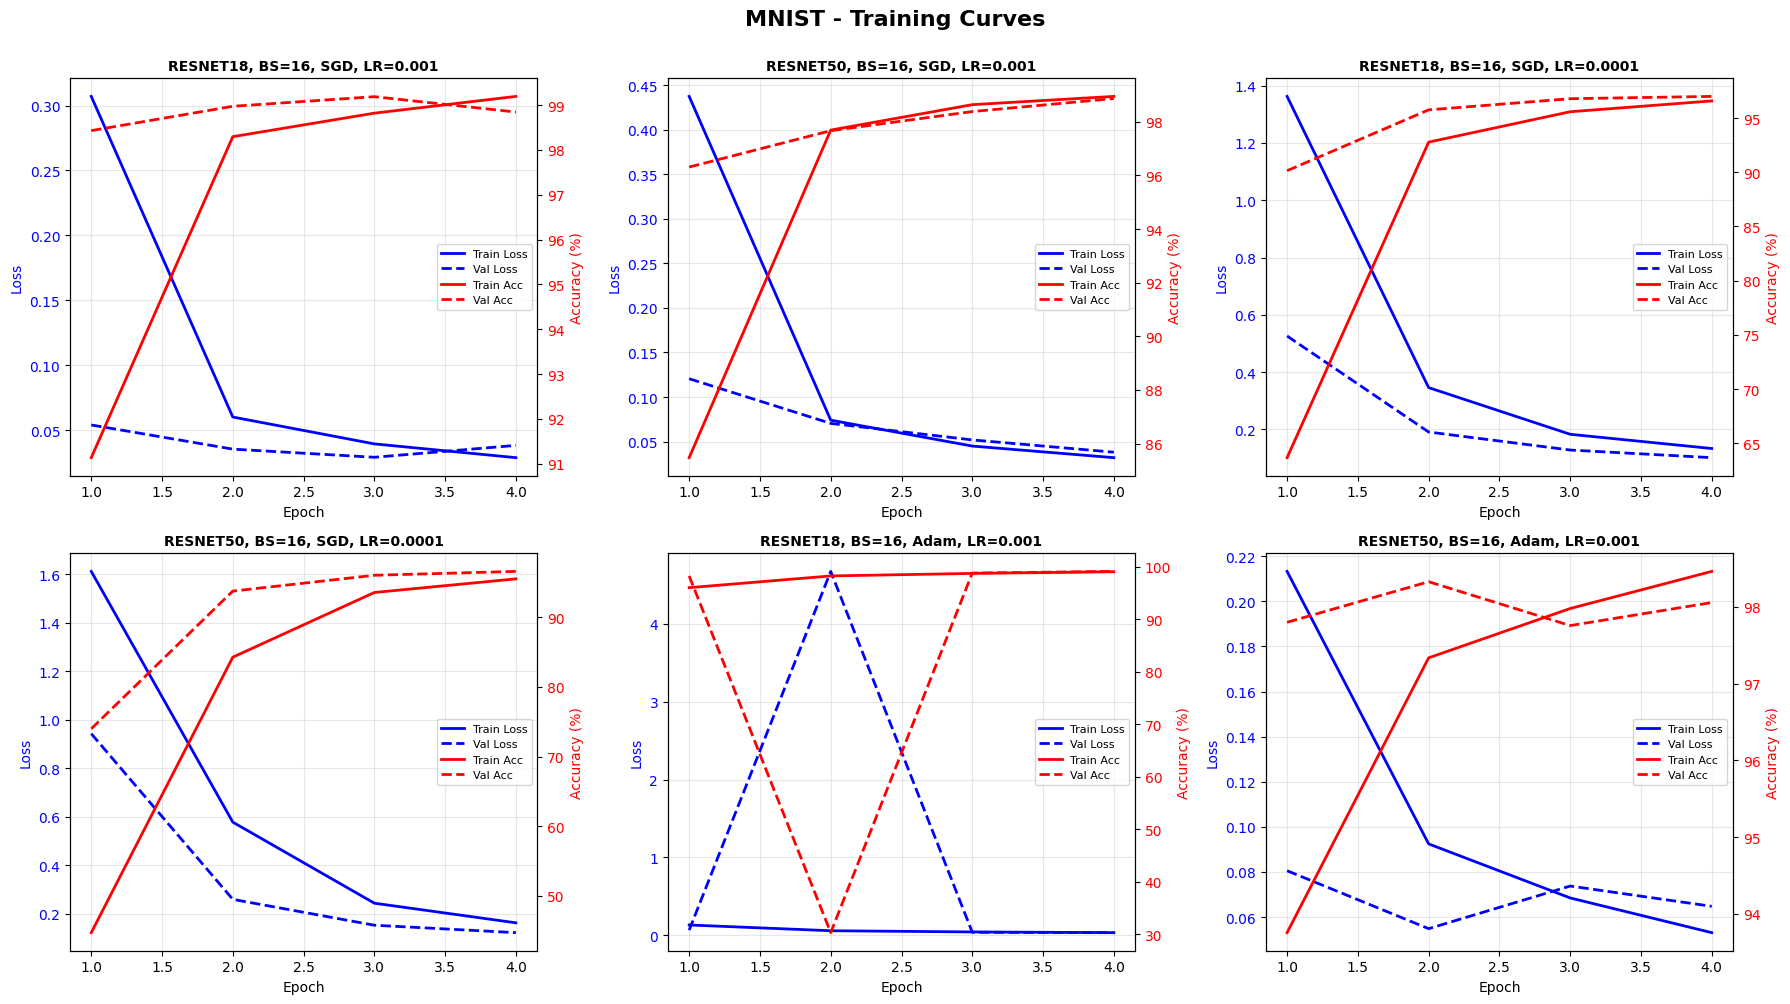

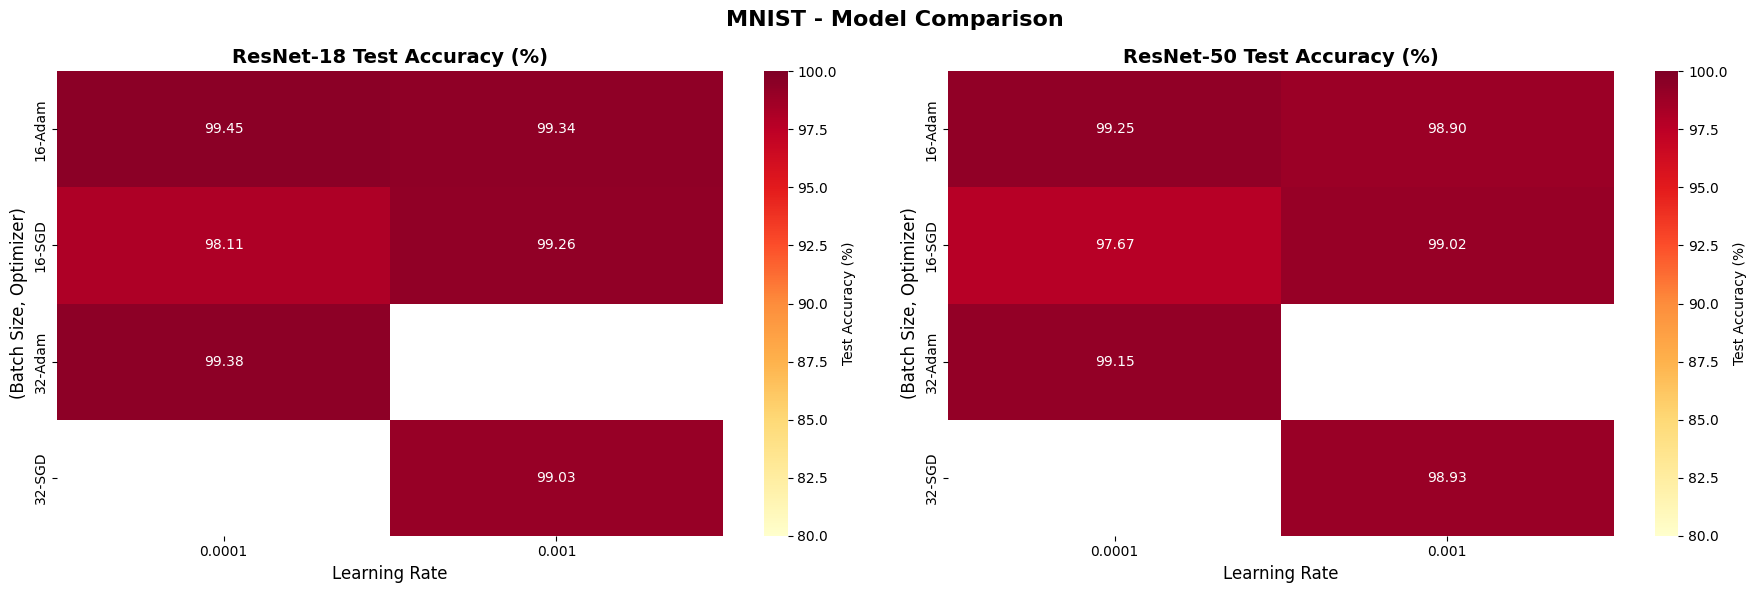

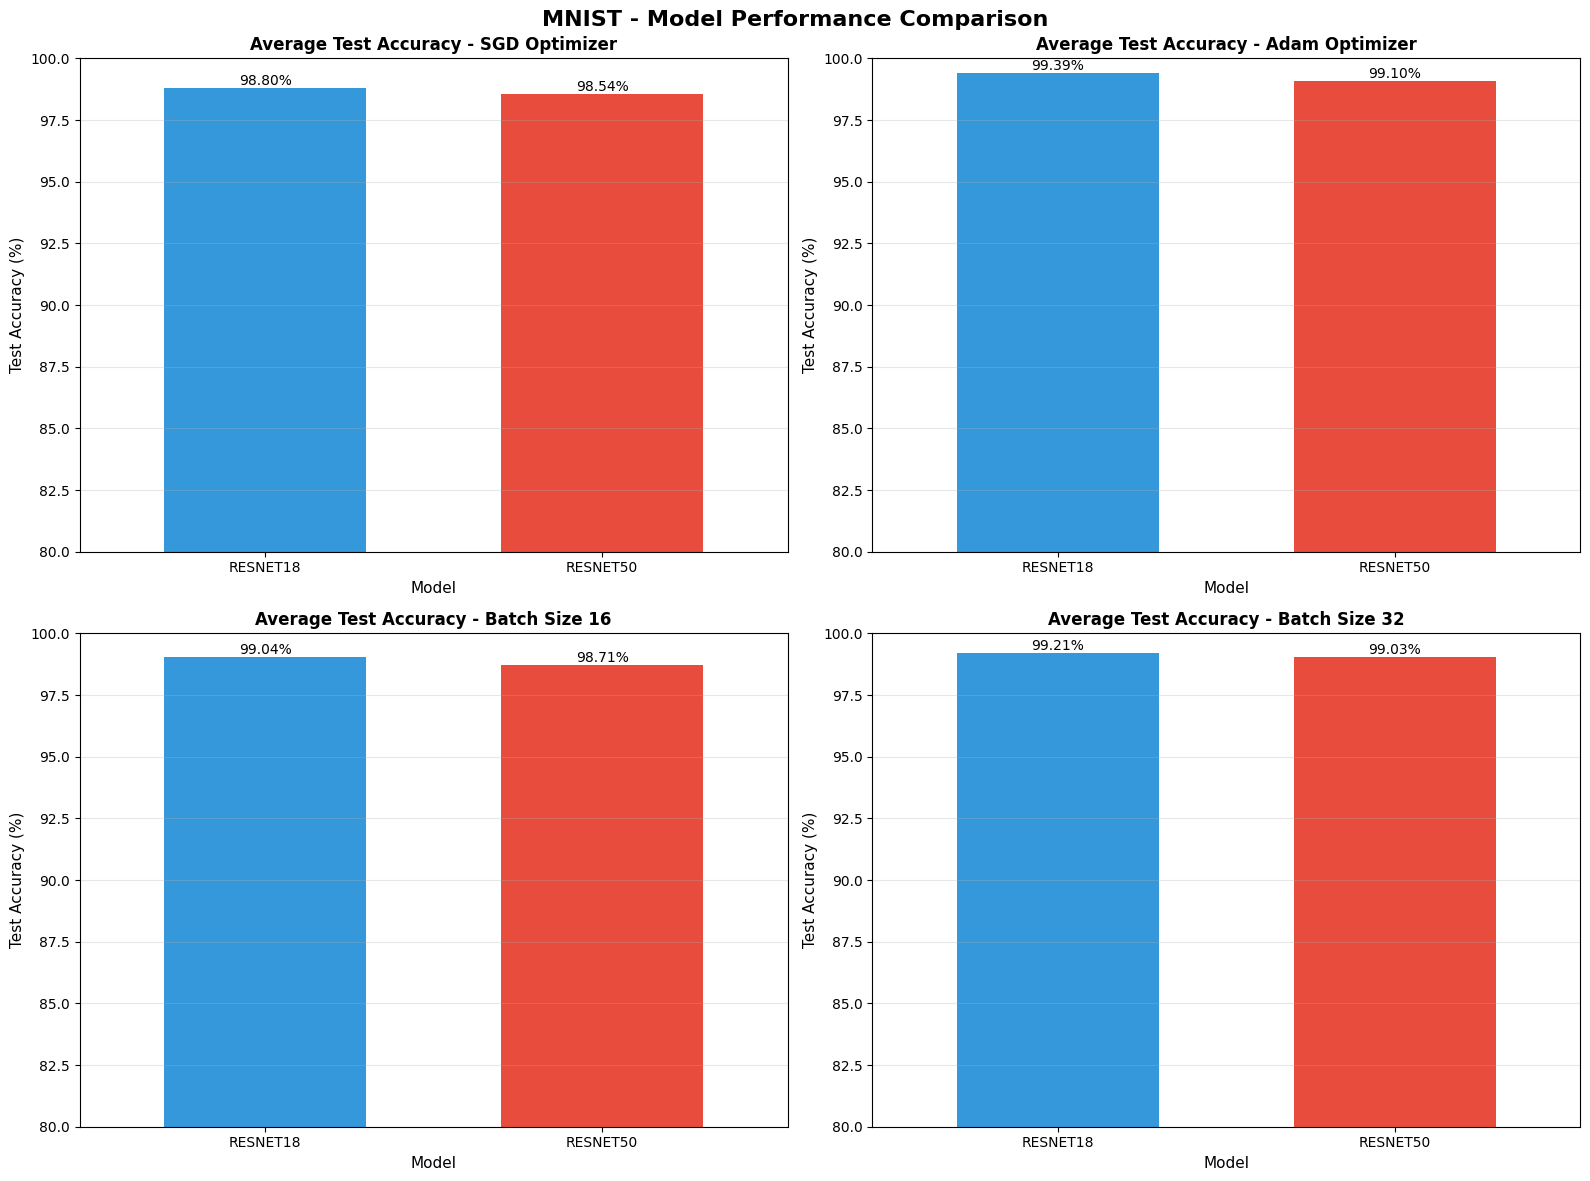

✓ MNIST visualizations saved


####################################################################################################
# FASHIONMNIST DATASET EXPERIMENTS
####################################################################################################

RUNNING 24 EXPERIMENTS ON FashionMNIST


[Experiment 1/24]

Training RESNET18 on FashionMNIST
Batch Size: 16, Optimizer: SGD, LR: 0.001
Epochs: 4, AMP: True


Preparing FashionMNIST dataset...
Dataset split: Train=49000, Val=7000, Test=10000

Epoch 1/4


Training:   0%|          | 0/3063 [00:00<?, ?it/s]

Validation:   0%|          | 0/438 [00:00<?, ?it/s]

Train Loss: 0.5739, Train Acc: 79.36%
Val Loss: 0.3536, Val Acc: 86.76%

Epoch 2/4


Training:   0%|          | 0/3063 [00:00<?, ?it/s]

...

Training:   0%|          | 0/1532 [00:00<?, ?it/s]

Validation:   0%|          | 0/219 [00:00<?, ?it/s]

Train Loss: 0.1147, Train Acc: 95.82%
Val Loss: 0.2154, Val Acc: 92.97%


Testing:   0%|          | 0/313 [00:00<?, ?it/s]


Best Val Accuracy: 92.99%
Final Test Accuracy: 92.23%


✓ Results saved to 'fashion_mnist_resnet_results.csv'

FashionMNIST - TEST CLASSIFICATION ACCURACY (in %)

4 EPOCHS:
----------------------------------------------------------------------------------------------------
Model                               RESNET18  RESNET50
Batch Size Optimizer Learning Rate                    
16         Adam      0.0001            92.27     91.14
                     0.0010            91.33     90.96
           SGD       0.0001            84.38     81.16
                     0.0010            90.92     90.66
32         Adam      0.0001            90.83     91.52
           SGD       0.0010            90.30     88.12

8 EPOCHS:
----------------------------------------------------------------------------------------------------
Model                               RESNET18  RESNET50
Batch Size Optimizer Learning Rate                    
16         Adam      0.0001            92.70     92.51
        

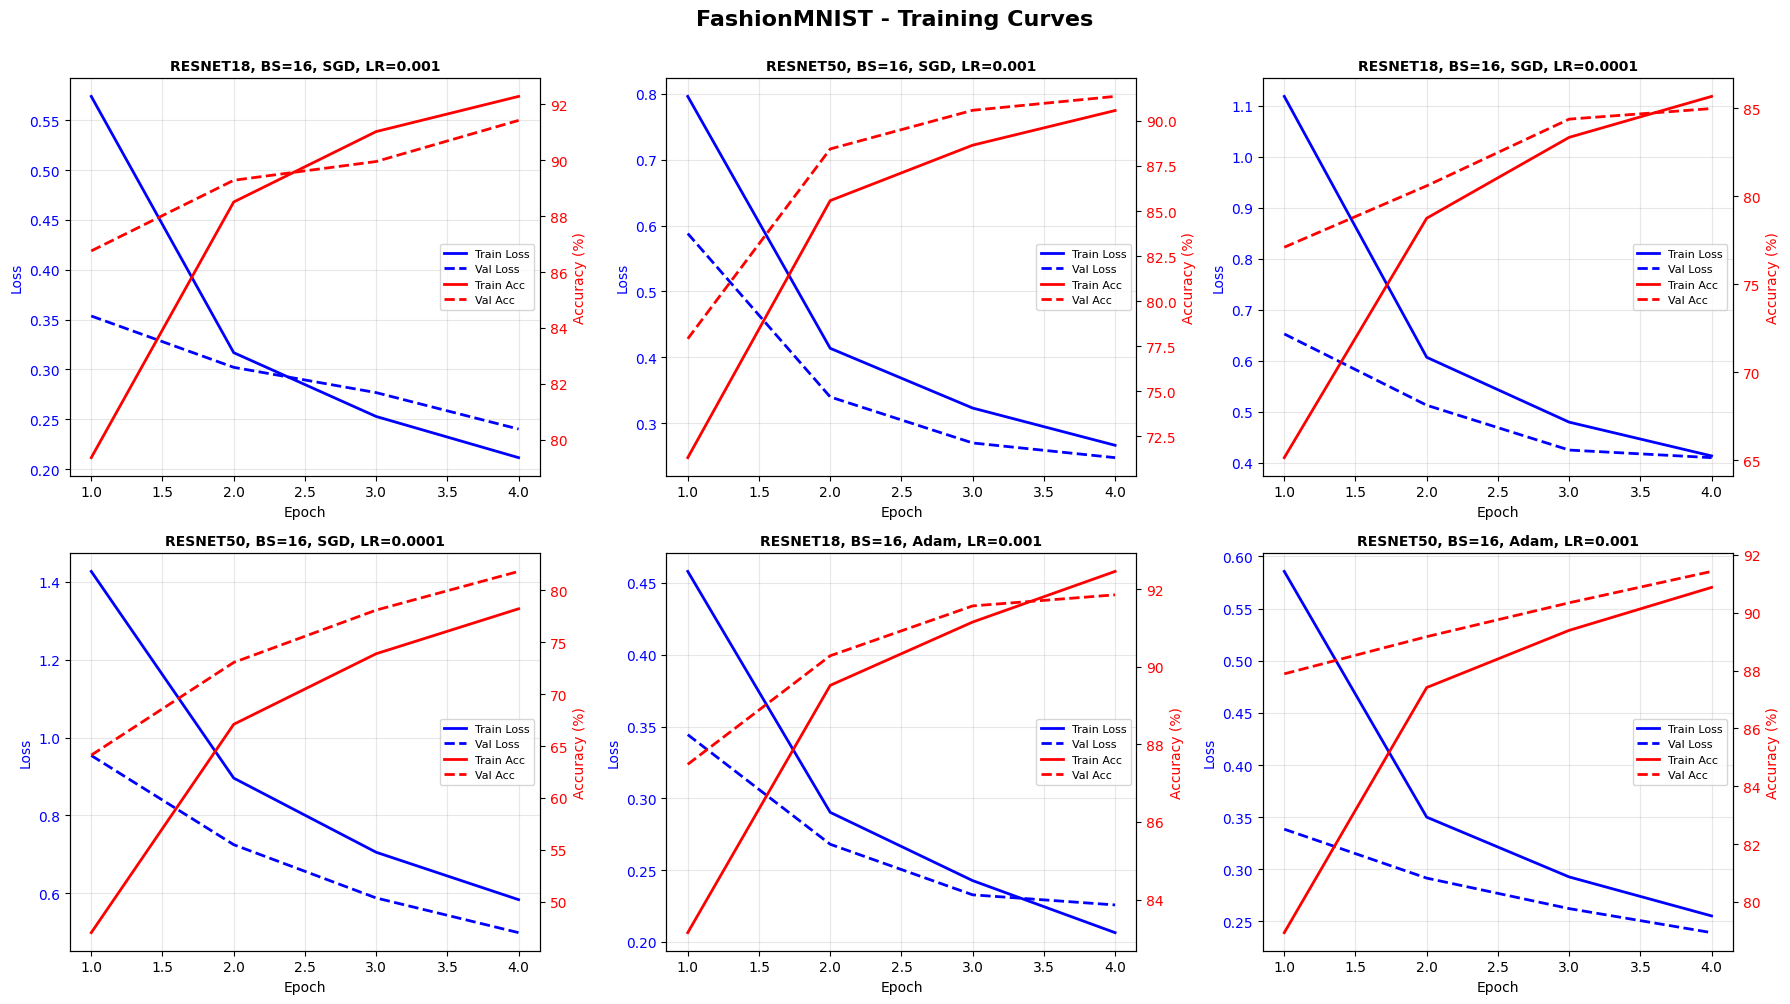

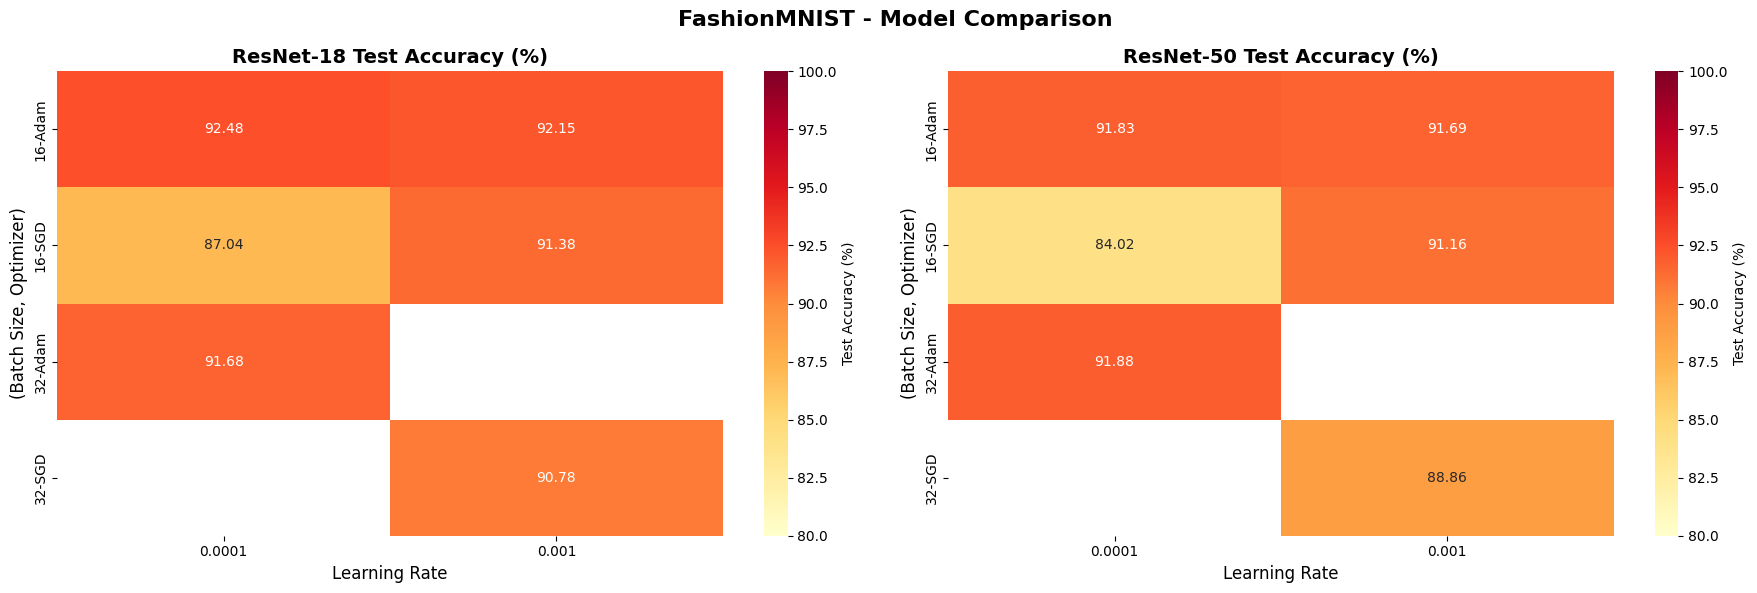

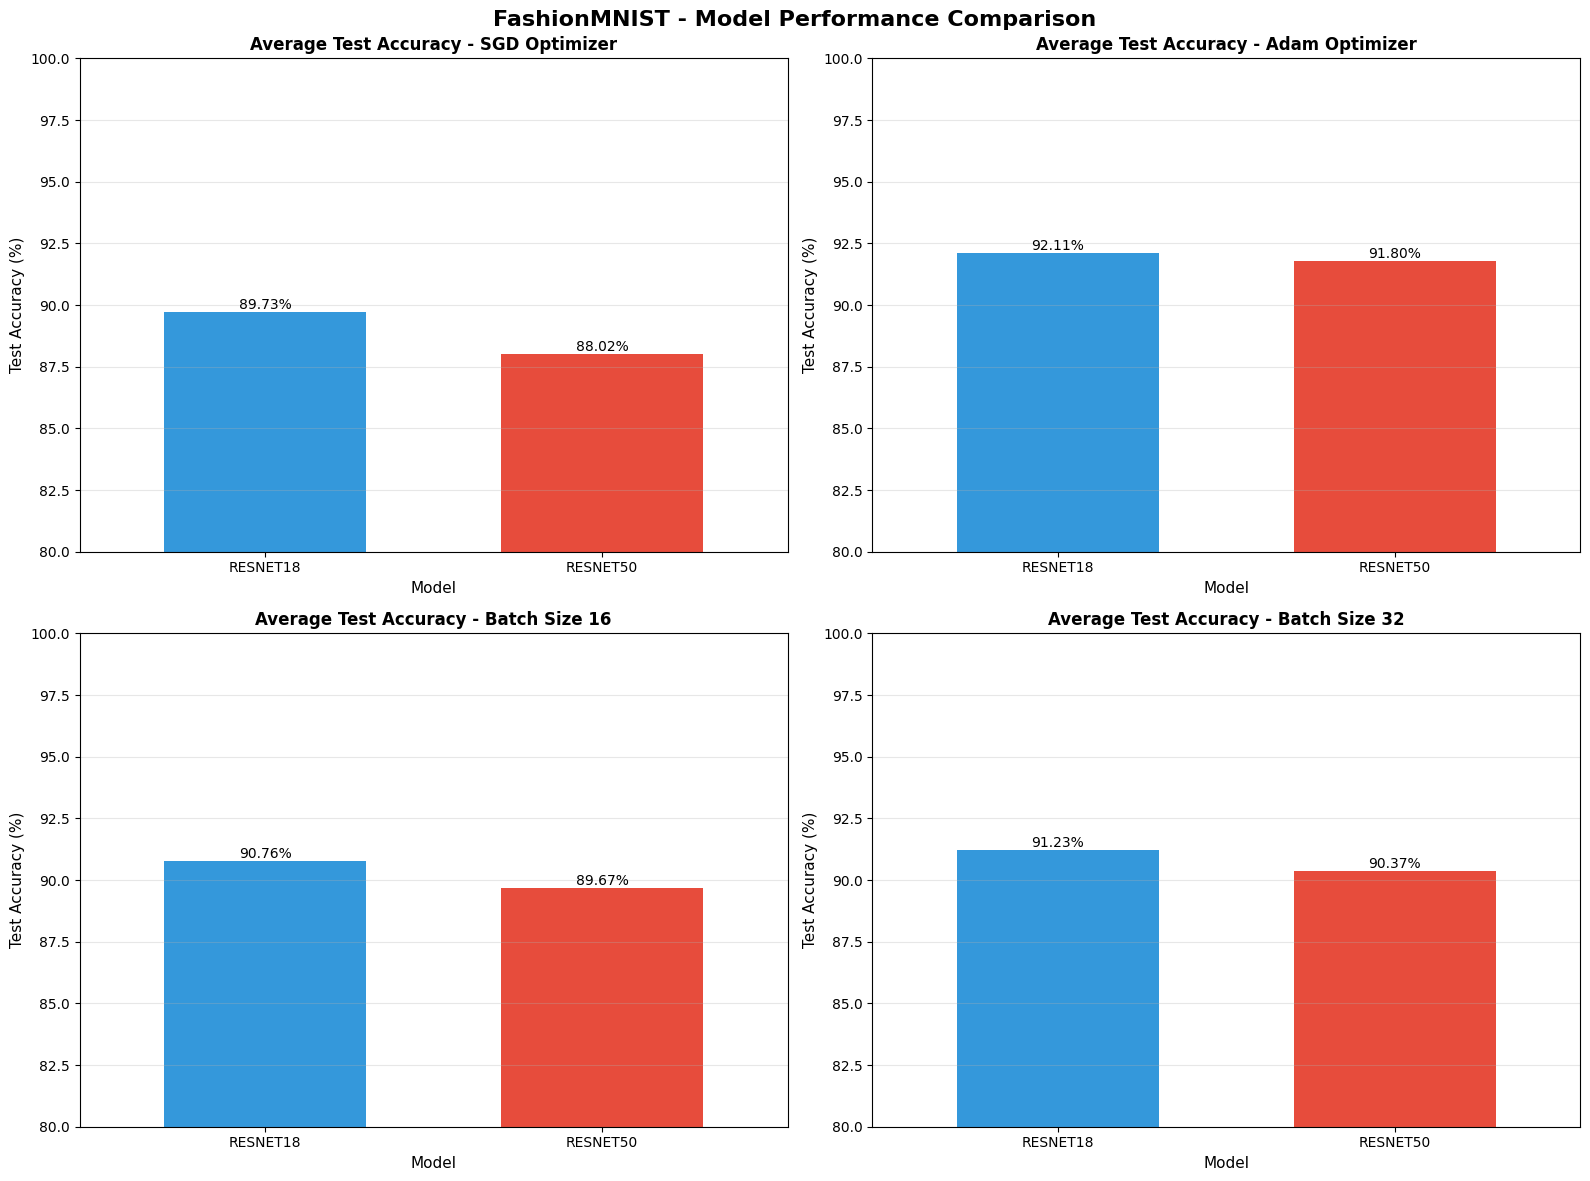

✓ FashionMNIST visualizations saved


FINAL SUMMARY - ALL EXPERIMENTS COMPLETED!

     Dataset  Total Experiments  Best Accuracy (%)  Average Accuracy (%)  Std Dev (%)  >80% Accuracy  >90% Accuracy
       MNIST                 24              99.53             98.957917     0.617055             24             24
FashionMNIST                 24              92.97             90.411667     2.797383             24             18

GENERATED FILES:
----------------------------------------------------------------------------------------------------
CSV Files:
  • mnist_resnet_results.csv
  • fashion_mnist_resnet_results.csv

Visualization Files:
  • mnist_training_curves.png
  • mnist_heatmap.png
  • mnist_model_comparison.png
  • fashion_training_curves.png
  • fashion_heatmap.png
  • fashion_model_comparison.png

✓ ALL EXPERIMENTS COMPLETED SUCCESSFULLY!



In [58]:
if __name__ == "__main__":
    print("\n" + "="*100)
    print("DEEP LEARNING EXPERIMENTS - RESNET ON MNIST AND FASHIONMNIST")
    print("="*100)
    print(f"\nDevice: {Config.DEVICE}")
    print(f"PyTorch Version: {torch.__version__}")
    print(f"CUDA Available: {torch.cuda.is_available()}")
    print(f"Mixed Precision (AMP): {Config.USE_AMP}")
    print(f"Number of Experiments per Dataset: {len(Config.EXPERIMENTS) * len(Config.EPOCHS_LIST) * 2}")
    
    # ========================================================================
    # MNIST EXPERIMENTS
    # ========================================================================
    print("\n\n" + "#"*100)
    print("# MNIST DATASET EXPERIMENTS")
    print("#"*100)
    
    mnist_results, mnist_histories = run_all_experiments(dataset_name='MNIST')
    
    # Save results
    mnist_results.to_csv('mnist_resnet_results.csv', index=False)
    print(f"\n✓ Results saved to 'mnist_resnet_results.csv'")
    
    # Generate results table
    generate_results_table(mnist_results, 'MNIST')
    
    # Plot visualizations
    print("Generating visualizations...")
    plot_training_curves(mnist_histories, 'MNIST', 'mnist_training_curves.png')
    plot_comparison_heatmap(mnist_results, 'MNIST', 'mnist_heatmap.png')
    plot_model_comparison(mnist_results, 'MNIST', 'mnist_model_comparison.png')
    print("✓ MNIST visualizations saved")
    
    # ========================================================================
    # FASHIONMNIST EXPERIMENTS
    # ========================================================================
    print("\n\n" + "#"*100)
    print("# FASHIONMNIST DATASET EXPERIMENTS")
    print("#"*100)
    
    fashion_results, fashion_histories = run_all_experiments(dataset_name='FashionMNIST')
    
    # Save results
    fashion_results.to_csv('fashion_mnist_resnet_results.csv', index=False)
    print(f"\n✓ Results saved to 'fashion_mnist_resnet_results.csv'")
    
    # Generate results table
    generate_results_table(fashion_results, 'FashionMNIST')
    
    # Plot visualizations
    print("Generating visualizations...")
    plot_training_curves(fashion_histories, 'FashionMNIST', 'fashion_training_curves.png')
    plot_comparison_heatmap(fashion_results, 'FashionMNIST', 'fashion_heatmap.png')
    plot_model_comparison(fashion_results, 'FashionMNIST', 'fashion_model_comparison.png')
    print("✓ FashionMNIST visualizations saved")
    
    # ========================================================================
    # FINAL SUMMARY
    # ========================================================================
    print("\n\n" + "="*100)
    print("FINAL SUMMARY - ALL EXPERIMENTS COMPLETED!")
    print("="*100)
    
    summary_data = []
    for dataset, results_df in [('MNIST', mnist_results), ('FashionMNIST', fashion_results)]:
        summary_data.append({
            'Dataset': dataset,
            'Total Experiments': len(results_df),
            'Best Accuracy (%)': results_df['Test Accuracy'].max(),
            'Average Accuracy (%)': results_df['Test Accuracy'].mean(),
            'Std Dev (%)': results_df['Test Accuracy'].std(),
            '>80% Accuracy': len(results_df[results_df['Test Accuracy'] > 80]),
            '>90% Accuracy': len(results_df[results_df['Test Accuracy'] > 90])
        })
    
    summary_df = pd.DataFrame(summary_data)
    print("\n" + summary_df.to_string(index=False))
    
    print("\n" + "="*100)
    print("GENERATED FILES:")
    print("-" * 100)
    print("CSV Files:")
    print("  • mnist_resnet_results.csv")
    print("  • fashion_mnist_resnet_results.csv")
    print("\nVisualization Files:")
    print("  • mnist_training_curves.png")
    print("  • mnist_heatmap.png")
    print("  • mnist_model_comparison.png")
    print("  • fashion_training_curves.png")
    print("  • fashion_heatmap.png")
    print("  • fashion_model_comparison.png")
    print("="*100)
    print("\n✓ ALL EXPERIMENTS COMPLETED SUCCESSFULLY!\n")

In [59]:
print("Q2 code and results as below")

Q2 code and results as below


In [77]:
import time
import copy
import math
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from ptflops import get_model_complexity_info
from tqdm import tqdm
import pandas as pd
import random
import numpy as np

In [74]:
BATCH_SIZE = 16
NUM_EPOCHS = 1  # user requested 1 epoch
LR = 0.001
SEED = 42
INPUT_CHANNELS = 1
INPUT_SIZE = (1, 28, 28)  # (C, H, W) for FLOPs measurement and model input
RESULTS_CSV = "q2results.csv"

In [75]:
MODEL_NAMES = ["resnet18", "resnet50"]
OPTIMIZERS = ["SGD", "Adam"]
DEVICES = ["cpu", "cuda"]  # will skip cuda if not available

In [78]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

In [79]:
transform = transforms.Compose([
    transforms.ToTensor(),  # FashionMNIST is grayscale 1x28x28
    # Do NOT normalize here; models still work. Add normalization if desired.
])

train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

num_train_samples = len(train_dataset)
num_test_samples = len(test_dataset)
num_batches = len(train_loader)

In [80]:
print(num_train_samples)

60000


In [81]:
def build_resnet(name: str, in_channels=INPUT_CHANNELS, num_classes=10):
    """
    Build a torchvision ResNet (pretrained=False) and adapt first conv for `in_channels`.
    name: 'resnet18' or 'resnet50'
    """
    if name == "resnet18":
        model = models.resnet18(pretrained=False)
    elif name == "resnet50":
        model = models.resnet50(pretrained=False)
    else:
        raise ValueError("Unsupported model name: " + name)
    # adapt conv1 to accept in_channels (FashionMNIST is 1-channel)
    # original: Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
    # adjust final fc
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [82]:
def compute_flops_and_params(model, input_res=INPUT_SIZE):
    # ptflops returns MACs and params
    model_cpu = copy.deepcopy(model).cpu().eval()
    with torch.no_grad():
        macs, params = get_model_complexity_info(model_cpu, input_res, as_strings=False, print_per_layer_stat=False)
    # macs here are MACs. FLOPs conventionally = 2 * MACs (multiply + add).
    flops = 2 * macs
    return macs, flops, params

In [83]:
def train_one_epoch(model, device, optimizer, criterion, loader):
    model.train()
    running_loss = 0.0
    total = 0
    correct = 0
    # synchronize and time
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.time()
    for inputs, targets in tqdm(loader, desc=f"Training on {device}", leave=False):
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        total += targets.size(0)
        correct += preds.eq(targets).sum().item()
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t1 = time.time()
    train_time_ms = (t1 - t0) * 1000.0
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc, train_time_ms

def evaluate(model, device, loader):
    model.eval()
    total = 0
    correct = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            total += targets.size(0)
            correct += preds.eq(targets).sum().item()
    acc = 100.0 * correct / total
    return acc

In [84]:
def run_experiment(model_name, optimizer_name, device_name):
    # check device availability
    if device_name == "cuda" and not torch.cuda.is_available():
        print(f"Skipping {model_name} on CUDA: CUDA not available.")
        return None

    device = torch.device(device_name)
    model = build_resnet(model_name, in_channels=INPUT_CHANNELS, num_classes=10)
    model.to(device)

    # compute FLOPs & params (use CPU copy for stable measurement)
    macs, flops, params = compute_flops_and_params(model, input_res=INPUT_SIZE)
    # compute estimated total FLOPs for one training epoch (forward+backward)
    # flops is FLOPs per forward pass per sample (we use FLOPs = 2*MACs).
    # For backward estimate, assume ~2x forward. So total per train-step = 3 * forward FLOPs.
    forward_flops_per_sample = flops
    total_training_steps = num_batches  # steps per epoch
    estimated_epoch_flops = forward_flops_per_sample * BATCH_SIZE * total_training_steps * 3.0  # forward+backward estimate

    # optimizer
    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=LR)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=LR)
    else:
        raise ValueError("Unknown optimizer: " + optimizer_name)

    criterion = nn.CrossEntropyLoss()

    # Train 1 epoch (user requested only 1 epoch)
    train_loss, train_acc, train_time_ms = train_one_epoch(model, device, optimizer, criterion, train_loader)

    # Evaluate on test set
    test_acc = evaluate(model, device, test_loader)

    result = {
        "Model": model_name,
        "Device": device_name,
        "Optimizer": optimizer_name,
        "LearningRate": LR,
        "BatchSize": BATCH_SIZE,
        "Epochs": NUM_EPOCHS,
        "TrainTime_ms": int(train_time_ms),
        "TrainAcc_pct": round(train_acc, 4),
        "TestAcc_pct": round(test_acc, 4),
        "MACs_per_sample": int(macs),
        "FLOPs_per_sample": int(flops),
        "Params": int(params),
        "Estimated_Epoch_FLOPs_total": int(estimated_epoch_flops)
    }
    return result

In [85]:
def main():
    results = []
    for device_name in DEVICES:
        # if cuda not available, skip
        if device_name == "cuda" and not torch.cuda.is_available():
            print("CUDA not available on this machine; GPU experiments will be skipped.")
            continue
        for model_name in MODEL_NAMES:
            for opt_name in OPTIMIZERS:
                print(f"\n=== Running: Model={model_name} | Device={device_name} | Optimizer={opt_name} ===")
                set_seed()  # reset seed each run for consistent behavior
                res = run_experiment(model_name, opt_name, device_name)
                if res is not None:
                    results.append(res)
                    # quick print
                    print(f"Result: Model={res['Model']} Device={res['Device']} Optimizer={res['Optimizer']} "
                          f"TestAcc={res['TestAcc_pct']}% TrainTime={res['TrainTime_ms']}ms "
                          f"FLOPs/sample={res['FLOPs_per_sample']:,} EstimatedEpochFLOPs={res['Estimated_Epoch_FLOPs_total']:,}")
    if results:
        df = pd.DataFrame(results)
        df.to_csv(RESULTS_CSV, index=False)
        print(f"\nAll done. Results saved to {RESULTS_CSV}")
        print(df[['Model','Device','Optimizer','TestAcc_pct','TrainTime_ms','FLOPs_per_sample','Estimated_Epoch_FLOPs_total']].to_string(index=False))
    else:
        print("No experiments were run (maybe CUDA not available and you configured only cuda?).")

In [86]:
if __name__ == "__main__":
    main()


=== Running: Model=resnet18 | Device=cpu | Optimizer=SGD ===


Result: Model=resnet18 Device=cpu Optimizer=SGD TestAcc=85.2% TrainTime=339685ms FLOPs/sample=66,403,860 EstimatedEpochFLOPs=11,952,694,800,000

=== Running: Model=resnet18 | Device=cpu | Optimizer=Adam ===


Result: Model=resnet18 Device=cpu Optimizer=Adam TestAcc=87.27% TrainTime=392958ms FLOPs/sample=66,403,860 EstimatedEpochFLOPs=11,952,694,800,000

=== Running: Model=resnet50 | Device=cpu | Optimizer=SGD ===


Result: Model=resnet50 Device=cpu Optimizer=SGD TestAcc=77.1% TrainTime=612882ms FLOPs/sample=157,452,820 EstimatedEpochFLOPs=28,341,507,600,000

=== Running: Model=resnet50 | Device=cpu | Optimizer=Adam ===


Result: Model=resnet50 Device=cpu Optimizer=Adam TestAcc=81.74% TrainTime=723654ms FLOPs/sample=157,452,820 EstimatedEpochFLOPs=28,341,507,600,000

=== Running: Model=resnet18 | Device=cuda | Optimizer=SGD ===


Result: Model=resnet18 Device=cuda Optimizer=SGD TestAcc=85.32% TrainTime=32334ms FLOPs/sample=66,403,860 EstimatedEpochFLOPs=11,952,694,800,000

=== Running: Model=resnet18 | Device=cuda | Optimizer=Adam ===


Result: Model=resnet18 Device=cuda Optimizer=Adam TestAcc=86.6% TrainTime=33521ms FLOPs/sample=66,403,860 EstimatedEpochFLOPs=11,952,694,800,000

=== Running: Model=resnet50 | Device=cuda | Optimizer=SGD ===


Result: Model=resnet50 Device=cuda Optimizer=SGD TestAcc=77.48% TrainTime=79184ms FLOPs/sample=157,452,820 EstimatedEpochFLOPs=28,341,507,600,000

=== Running: Model=resnet50 | Device=cuda | Optimizer=Adam ===


Result: Model=resnet50 Device=cuda Optimizer=Adam TestAcc=82.21% TrainTime=86606ms FLOPs/sample=157,452,820 EstimatedEpochFLOPs=28,341,507,600,000

All done. Results saved to q2results.csv
   Model Device Optimizer  TestAcc_pct  TrainTime_ms  FLOPs_per_sample  Estimated_Epoch_FLOPs_total
resnet18    cpu       SGD        85.20        339685          66403860               11952694800000
resnet18    cpu      Adam        87.27        392958          66403860               11952694800000
resnet50    cpu       SGD        77.10        612882         157452820               28341507600000
resnet50    cpu      Adam        81.74        723654         157452820               28341507600000
resnet18   cuda       SGD        85.32         32334          66403860               11952694800000
resnet18   cuda      Adam        86.60         33521          66403860               11952694800000
resnet50   cuda       SGD        77.48         79184         157452820               28341507600000
resnet50   